NOTE: VEP annotation of all guides

In [254]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm
import math

In [255]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [256]:
#zscores file
#EG_zscores_smooth_hits= pd.read_excel("data/plots/FindHits/EG_zscores_smooth_hits.xlsx")
#EG_zscores = pd.read_csv("data/4_Screen_zscores/EG/EG_zscores_min.csv")
#MC_zscores = pd.read_csv("data/4_Screen_zscores/MC/MC_zscores_min.csv")
#zscores = pd.read_csv("data/Testing/All_hits_original_(1columncondition_duplicatedGuides).csv", sep=",")
zscores_control = pd.read_csv("data/4_Screen_zscores/Merge_Control.csv")
zscores_plasmid = pd.read_csv("data/4_Screen_zscores/Merge_Plasmid.csv")

In [257]:
#Beagle-generated file EG
EG_beagle = pd.read_csv("data/1_Beagle_design_files/EG/EG-guides.txt", sep="\t")
MC_beagle = pd.read_csv("data/1_Beagle_design_files/MC/MC_guides.txt", sep="\t")

# Data Inspection

In [98]:
print(f'z-scores control shape: {zscores_control.shape}')
print(f'z-scores plasmid shape: {zscores_plasmid.shape}')

z-scores control shape: (77877, 18)
z-scores plasmid shape: (77877, 24)


In [258]:
for col in zscores_control.columns:
    print(col)

Guide
Gene
Editor
A375_PIC_Control
A375_SCH_Control
A375_LIN_Control
HT29_PIC_Control_EG
HT29_SCH_Control
HT29_LIN_Control
H23_ADAG_Control
H23_SOTOR_Control
HT29_DEB-CET_Control
HT29_PIC_Control_MC
HT29_TRAM_Control
PC9_GEFIT_Control
PC9_OSIM_Control
MHHES1_NIRAP_Control
MHHES1_OLAP_Control


In [259]:
for col in zscores_plasmid.columns:
    print(col)

Guide
Gene
Editor
A375_PIC_Plasmid
A375_SCH_Plasmid
A375_LIN_Plasmid
HT29_PIC_Plasmid_EG
HT29_SCH_Plasmid
HT29_LIN_Plasmid
A375_DO_Plasmid
HT29_DO_Plasmid
H23_ADAG_Plasmid
H23_SOTOR_Plasmid
HT29_DEB-CET_Plasmid
HT29_PIC_Plasmid_MC
HT29_TRAM_Plasmid
PC9_GEFIT_Plasmid
PC9_OSIM_Plasmid
MHHES1_NIRAP_Plasmid
MHHES1_OLAP_Plasmid
H23_Control_Plasmid
HT29_Control_Plasmid
PC9_Control_Plasmid
MHHES1_Control_Plasmid


### Duplicates

In [101]:
#Check duplicates
duplicates = zscores_control[zscores_control.duplicated(subset=['Guide', 'Editor'], keep=False)]
duplicates = duplicates.sort_values(by='Guide')
duplicates.head()

,Guide,Gene,Editor,A375_PIC_Control,A375_SCH_Control,A375_LIN_Control,HT29_PIC_Control_EG,HT29_SCH_Control,HT29_LIN_Control,H23_ADAG_Control,H23_SOTOR_Control,HT29_DEB-CET_Control,HT29_PIC_Control_MC,HT29_TRAM_Control,PC9_GEFIT_Control,PC9_OSIM_Control,MHHES1_NIRAP_Control,MHHES1_OLAP_Control
3676,AAGGTCATCAACTCCCAAAC,ERBB3,CBE,-0.511926,-0.232892,0.532032,-0.033422,-1.180418,-0.650421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3678,AAGGTCATCAACTCCCAAAC,EGFR,CBE,-0.511926,-0.232892,0.532032,-0.033422,-1.180418,-0.650421,0.170892,-1.059833,0.705661,0.317864,-1.108477,0.130915,-1.076500,NaN,NaN
11661,AGCTCCAGACATCACTCTGG,EGFR,CBE,-0.163528,-0.289178,0.853565,0.808474,-4.909782,-0.739178,-1.652807,0.581957,0.158576,-0.426644,-6.016470,1.512103,-0.585263,NaN,NaN
11662,AGCTCCAGACATCACTCTGG,ERBB3,CBE,-0.163528,-0.289178,0.853565,0.808474,-4.909782,-0.739178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14420,AGTTGGCCATGGAGTCGATG,MAP2K1,CBE,0.547827,-1.571410,-1.803915,-0.886750,-1.336677,-0.050817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
len(duplicates)

40

In [103]:
zscores_plasmid.head()

,Guide,Gene,Editor,A375_PIC_Plasmid,A375_SCH_Plasmid,A375_LIN_Plasmid,HT29_PIC_Plasmid_EG,HT29_SCH_Plasmid,HT29_LIN_Plasmid,A375_DO_Plasmid,HT29_DO_Plasmid,H23_ADAG_Plasmid,H23_SOTOR_Plasmid,HT29_DEB-CET_Plasmid,HT29_PIC_Plasmid_MC,HT29_TRAM_Plasmid,PC9_GEFIT_Plasmid,PC9_OSIM_Plasmid,MHHES1_NIRAP_Plasmid,MHHES1_OLAP_Plasmid,H23_Control_Plasmid,HT29_Control_Plasmid,PC9_Control_Plasmid,MHHES1_Control_Plasmid
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339885,-0.435793,-0.130954,0.150758,-0.000405,-0.267878,-0.265840,0.749878,0.623857,-0.793901,0.248229,-0.087339,0.352839
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239891,-0.425877,0.509103,-0.343729,0.275384,0.167677,-0.163542,NaN,NaN,-0.605231,-0.248019,-0.133027,NaN
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.288042,-0.084146,0.023579,0.232187,0.149661,0.410165,0.176574,0.609217,0.310484,0.040756,-0.173223,0.297107,0.650107
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.193041,-0.125730,0.252409,-0.025515,0.031043,-0.760856,-0.054741,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.125899,-0.283770,-0.221515,0.628496,0.313693,0.381266,0.106376,-0.790841,0.117541,1.152411,0.029326,0.044886,-0.840669


# Classify Hits

In [260]:
def classify_hits(X_):
    X=X_.copy()
    exclude_cols = ['Guide', 'Gene', 'Editor'] 
    zscore_cols = [col for col in X.columns if col not in exclude_cols]

    for cond in zscore_cols:
        print(f"Processing condition: {cond}")

        all_z = X[cond]
        neg_ctrl_z = X.loc[X['Gene'] == 'Intergenic control', cond]

        mu = neg_ctrl_z.mean(skipna=True)
        sigma = neg_ctrl_z.std(skipna=True)

        # Initialize pvals and fdrs with NaNs
        pvals = np.full_like(all_z, np.nan, dtype=np.float64)
        fdrs = np.full_like(all_z, np.nan, dtype=np.float64)

        # Indices where all_z is not NaN
        valid_idx = all_z.notna()

        # Compute p-values only for valid entries
        z_scores = (all_z[valid_idx] - mu) / sigma
        pvals_valid = 2 * norm.sf(np.abs(z_scores))

        # FDR correction
        _, fdrs_valid, _, _ = multipletests(pvals_valid, alpha=0.05, method='fdr_bh')

        # Assign back to full arrays
        pvals[valid_idx] = pvals_valid
        fdrs[valid_idx] = fdrs_valid

        # Add results to dataframe
        X[f"{cond}_pval"] = pvals
        X[f"{cond}_fdr"] = fdrs

        print(f"Condition: {cond}")
        print(f"Negative controls count: {neg_ctrl_z.count()}")
        print(f"Negative control mean: {mu}, std: {sigma}")
        print(f"Any NaN in pvals? {np.isnan(pvals).any()}")
        print(f"All finite pvals? {np.isfinite(pvals[valid_idx]).all()}")


    def classify_hit(z, fdr, threshold=0.05):
        if fdr < threshold:
            if z > 0:
                return "positive"
            elif z < 0:
                return "negative"
        return "non-hit"

    for cond in zscore_cols:
        z_col = cond
        fdr_col = f"{cond}_fdr"
        label_col = f"{cond}_hit"

        X[label_col] = X.apply(
            lambda row: classify_hit(row[z_col], row[fdr_col]),
            axis=1
        )
    return X

In [261]:
zscores_plasmid= classify_hits(zscores_plasmid)

Processing condition: A375_PIC_Plasmid
Condition: A375_PIC_Plasmid
Negative controls count: 1000
Negative control mean: -0.027148615887439064, std: 0.3926930375214831
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_SCH_Plasmid
Condition: A375_SCH_Plasmid
Negative controls count: 1000
Negative control mean: -0.1271931598541124, std: 0.5424318260656481
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_LIN_Plasmid
Condition: A375_LIN_Plasmid
Negative controls count: 1000
Negative control mean: -0.015733007259847595, std: 0.4407530921231039
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_PIC_Plasmid_EG
Condition: HT29_PIC_Plasmid_EG
Negative controls count: 1000
Negative control mean: -0.016864778139225885, std: 0.3787441709216337
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_SCH_Plasmid
Condition: HT29_SCH_Plasmid
Negative controls count: 1000
Negative control mean: -0.06496652858053265, st

In [106]:
zscores_control= classify_hits(zscores_control)

Processing condition: A375_PIC_Control
Condition: A375_PIC_Control
Negative controls count: 1000
Negative control mean: -0.04645351150914961, std: 0.47757473122379174
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_SCH_Control
Condition: A375_SCH_Control
Negative controls count: 1000
Negative control mean: -0.11135565114845818, std: 0.5800013640806186
Any NaN in pvals? True
All finite pvals? True
Processing condition: A375_LIN_Control
Condition: A375_LIN_Control
Negative controls count: 1000
Negative control mean: 0.015555588506451633, std: 0.5573334384291886
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_PIC_Control_EG
Condition: HT29_PIC_Control_EG
Negative controls count: 1000
Negative control mean: 0.00627849283928432, std: 0.5317456084054537
Any NaN in pvals? True
All finite pvals? True
Processing condition: HT29_SCH_Control
Condition: HT29_SCH_Control
Negative controls count: 1000
Negative control mean: -0.02061344766192496, std:

In [262]:
zscores_plasmid.head()

,Guide,Gene,Editor,A375_PIC_Plasmid,A375_SCH_Plasmid,A375_LIN_Plasmid,HT29_PIC_Plasmid_EG,HT29_SCH_Plasmid,HT29_LIN_Plasmid,A375_DO_Plasmid,HT29_DO_Plasmid,H23_ADAG_Plasmid,H23_SOTOR_Plasmid,HT29_DEB-CET_Plasmid,HT29_PIC_Plasmid_MC,HT29_TRAM_Plasmid,PC9_GEFIT_Plasmid,PC9_OSIM_Plasmid,MHHES1_NIRAP_Plasmid,MHHES1_OLAP_Plasmid,H23_Control_Plasmid,HT29_Control_Plasmid,PC9_Control_Plasmid,MHHES1_Control_Plasmid,A375_PIC_Plasmid_pval,A375_PIC_Plasmid_fdr,A375_SCH_Plasmid_pval,A375_SCH_Plasmid_fdr,A375_LIN_Plasmid_pval,A375_LIN_Plasmid_fdr,HT29_PIC_Plasmid_EG_pval,HT29_PIC_Plasmid_EG_fdr,HT29_SCH_Plasmid_pval,HT29_SCH_Plasmid_fdr,HT29_LIN_Plasmid_pval,HT29_LIN_Plasmid_fdr,A375_DO_Plasmid_pval,A375_DO_Plasmid_fdr,HT29_DO_Plasmid_pval,HT29_DO_Plasmid_fdr,H23_ADAG_Plasmid_pval,H23_ADAG_Plasmid_fdr,H23_SOTOR_Plasmid_pval,H23_SOTOR_Plasmid_fdr,HT29_DEB-CET_Plasmid_pval,HT29_DEB-CET_Plasmid_fdr,HT29_PIC_Plasmid_MC_pval,HT29_PIC_Plasmid_MC_fdr,HT29_TRAM_Plasmid_pval,HT29_TRAM_Plasmid_fdr,PC9_GEFIT_Plasmid_pval,PC9_GEFIT_Plasmid_fdr,PC9_OSIM_Plasmid_pval,PC9_OSIM_Plasmid_fdr,MHHES1_NIRAP_Plasmid_pval,MHHES1_NIRAP_Plasmid_fdr,MHHES1_OLAP_Plasmid_pval,MHHES1_OLAP_Plasmid_fdr,H23_Control_Plasmid_pval,H23_Control_Plasmid_fdr,HT29_Control_Plasmid_pval,HT29_Control_Plasmid_fdr,PC9_Control_Plasmid_pval,PC9_Control_Plasmid_fdr,MHHES1_Control_Plasmid_pval,MHHES1_Control_Plasmid_fdr,A375_PIC_Plasmid_hit,A375_SCH_Plasmid_hit,A375_LIN_Plasmid_hit,HT29_PIC_Plasmid_EG_hit,HT29_SCH_Plasmid_hit,HT29_LIN_Plasmid_hit,A375_DO_Plasmid_hit,HT29_DO_Plasmid_hit,H23_ADAG_Plasmid_hit,H23_SOTOR_Plasmid_hit,HT29_DEB-CET_Plasmid_hit,HT29_PIC_Plasmid_MC_hit,HT29_TRAM_Plasmid_hit,PC9_GEFIT_Plasmid_hit,PC9_OSIM_Plasmid_hit,MHHES1_NIRAP_Plasmid_hit,MHHES1_OLAP_Plasmid_hit,H23_Control_Plasmid_hit,HT29_Control_Plasmid_hit,PC9_Control_Plasmid_hit,MHHES1_Control_Plasmid_hit
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339885,-0.435793,-0.130954,0.150758,-0.000405,-0.267878,-0.265840,0.749878,0.623857,-0.793901,0.248229,-0.087339,0.352839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.470665,0.999998,0.392298,0.999971,0.970618,0.999923,0.689856,0.999835,0.851306,0.999954,0.309412,0.924018,0.926184,0.999896,0.184212,0.999916,0.252963,0.999974,0.133826,0.943126,0.632012,0.999923,0.416825,0.999814,0.439918,0.995291,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239891,-0.425877,0.509103,-0.343729,0.275384,0.167677,-0.163542,NaN,NaN,-0.605231,-0.248019,-0.133027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655863,0.999998,0.403147,0.999971,0.476851,0.999923,0.866767,0.999835,0.617693,0.999954,0.551400,0.924018,0.985059,0.999896,NaN,NaN,NaN,NaN,0.251700,0.999991,0.929927,0.999923,0.364566,0.999814,NaN,NaN,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.288042,-0.084146,0.023579,0.232187,0.149661,0.410165,0.176574,0.609217,0.310484,0.040756,-0.173223,0.297107,0.650107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.587436,0.999998,0.868197,0.999971,0.841720,0.999923,0.622444,0.999835,0.721060,0.999954,0.717806,0.934848,0.697262,0.999896,0.258957,0.999916,0.464710,0.999974,0.950366,0.999991,0.998005,0.999923,0.988336,0.999814,0.251370,0.995291,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.193041,-0.125730,0.252409,-0.025515,0.031043,-0.760856,-0.054741,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [108]:
zscores_control.head()

,Guide,Gene,Editor,A375_PIC_Control,A375_SCH_Control,A375_LIN_Control,HT29_PIC_Control_EG,HT29_SCH_Control,HT29_LIN_Control,H23_ADAG_Control,H23_SOTOR_Control,HT29_DEB-CET_Control,HT29_PIC_Control_MC,HT29_TRAM_Control,PC9_GEFIT_Control,PC9_OSIM_Control,MHHES1_NIRAP_Control,MHHES1_OLAP_Control,A375_PIC_Control_pval,A375_PIC_Control_fdr,A375_SCH_Control_pval,A375_SCH_Control_fdr,A375_LIN_Control_pval,A375_LIN_Control_fdr,HT29_PIC_Control_EG_pval,HT29_PIC_Control_EG_fdr,HT29_SCH_Control_pval,HT29_SCH_Control_fdr,HT29_LIN_Control_pval,HT29_LIN_Control_fdr,H23_ADAG_Control_pval,H23_ADAG_Control_fdr,H23_SOTOR_Control_pval,H23_SOTOR_Control_fdr,HT29_DEB-CET_Control_pval,HT29_DEB-CET_Control_fdr,HT29_PIC_Control_MC_pval,HT29_PIC_Control_MC_fdr,HT29_TRAM_Control_pval,HT29_TRAM_Control_fdr,PC9_GEFIT_Control_pval,PC9_GEFIT_Control_fdr,PC9_OSIM_Control_pval,PC9_OSIM_Control_fdr,MHHES1_NIRAP_Control_pval,MHHES1_NIRAP_Control_fdr,MHHES1_OLAP_Control_pval,MHHES1_OLAP_Control_fdr,A375_PIC_Control_hit,A375_SCH_Control_hit,A375_LIN_Control_hit,HT29_PIC_Control_EG_hit,HT29_SCH_Control_hit,HT29_LIN_Control_hit,H23_ADAG_Control_hit,H23_SOTOR_Control_hit,HT29_DEB-CET_Control_hit,HT29_PIC_Control_MC_hit,HT29_TRAM_Control_hit,PC9_GEFIT_Control_hit,PC9_OSIM_Control_hit,MHHES1_NIRAP_Control_hit,MHHES1_OLAP_Control_hit
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,0.349536,0.281788,-0.092111,-0.440937,0.237055,-0.323425,-0.429644,0.742707,0.546180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.524412,0.999906,0.655426,0.999922,0.997439,0.999989,0.433216,0.999895,0.629344,0.999981,0.398025,0.999923,0.527876,0.999968,0.188228,0.99999,0.360334,0.999841,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,0.801893,-0.404665,1.183724,0.174917,0.862387,0.509532,-0.063357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.156096,0.999906,0.413401,0.999922,0.043031,0.802780,0.809659,0.999895,0.090728,0.865653,0.760095,0.999923,0.857772,0.999968,NaN,NaN,NaN,NaN,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,0.346023,0.635084,0.050661,0.711641,0.578670,-0.279569,-0.361358,-0.079732,0.226823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.528375,0.999906,0.272703,0.999922,0.818652,0.999989,0.256884,0.999895,0.253007,0.999981,0.432701,0.999923,0.584393,0.999968,0.942499,0.99999,0.701387,0.999841,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,-0.339015,0.169475,-0.652642,-0.273429,-0.103004,-0.428180,0.882738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.579992,0.999906,0.810793,0.999922,0.376506,0.999989,0.613541,0.999895,0.861261,0.999981,0.322250,0.999923,0.322964,0.999968,NaN,NaN,NaN,NaN,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,NaN,NaN,NaN,NaN,NaN,NaN,-0.042433,1.692755,0.481643,1.075654,0.700159,-0.779421,-0.548121,-0.228105,-0.752463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.967422,0.999906,0.002330,0.176194,0.361922,0.999989,0.081968,0.983793,0.168220,0.972927,0.140215,0.999923,0.436883,0.999968,0.747052,0.99999,0.212880,0.999841,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit,non-hit


In [13]:
#export to csv
zscores_plasmid.to_csv("data/4_Screen_zscores/Merge_Plasmid_Hit_Class.csv", index=False)

# Preprocessing

In [263]:
#Dataframe to keep track of the numbers of rows throughout the process
tracking_row_count_plasmid = pd.DataFrame(columns=["Step", "Rows count"])
tracking_row_count_control = pd.DataFrame(columns=["Step", "Rows count"])

# Function to log the number of rows at each step
def log_step(tracking_row_count, step_name, df):
    new_entry = pd.DataFrame({"Step": [step_name], "Rows count": [len(df)]})
    return pd.concat([tracking_row_count, new_entry], ignore_index=True)

In [264]:
#Dataframe to keep track of the numbers of unique guides throughout the process
tracking_unique_guides_plasmid = pd.DataFrame(columns=["Step", "Unique guides count"])
tracking_unique_guides_control = pd.DataFrame(columns=["Step", "Unique guides count"])

# Function to log the number of unique guides at each step
def log_unique_guides(tracking_unique_guides, step_name, df):
    new_entry = pd.DataFrame({"Step": [step_name], "Unique guides count": [df['Guide'].nunique()]})
    return pd.concat([tracking_unique_guides, new_entry], ignore_index=True)

In [265]:
#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Initial z-scores", zscores_plasmid)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Initial z-scores", zscores_plasmid)

#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Initial z-scores", zscores_control)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Initial z-scores", zscores_control)

In [266]:
tracking_unique_guides_control

,Step,Unique guides count
0,Initial z-scores,55041


In [116]:
tracking_row_count_control

,Step,Rows count
0,Initial z-scores,77877


### Eliminate guides that target two different genes 

In [267]:
guides_target_dif_genes_EG = EG_beagle[EG_beagle.duplicated(subset=['sgRNA Sequence', 'Edit Type'], keep=False)]
guides_target_dif_genes_EG = guides_target_dif_genes_EG.sort_values(by=['sgRNA Sequence', 'Edit Type'])
guides_target_dif_genes_EG.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
3054,ENST00000275493.7,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AAGGTCATCAACTCCCAAAC,TCCAAAGGTCATCAACTCCCAAACAGTCAC,AG,55198725,antisense,55198738T>C,A_7,2723T>C,Met908Thr,Missense,NaN,NaN
12712,ENST00000267101.8,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000012.12,ENSG00000065361,ERBB3,+,ENST00000267101.8,CDS,AAGGTCATCAACTCCCAAAC,CCCGAAGGTCATCAACTCCCAAACTGTCAC,TG,56098767,antisense,56098780T>C,A_7,2714T>C,Met905Thr,Missense,NaN,NaN
3055,ENST00000275493.7,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AAGGTCATCAACTCCCAAAC,TCCAAAGGTCATCAACTCCCAAACAGTCAC,AG,55198725,antisense,55198739G>A,C_6,2724G>A,Met908Ile,Missense,NaN,NaN
12713,ENST00000267101.8,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000012.12,ENSG00000065361,ERBB3,+,ENST00000267101.8,CDS,AAGGTCATCAACTCCCAAAC,CCCGAAGGTCATCAACTCCCAAACTGTCAC,TG,56098767,antisense,56098781G>A,C_6,2715G>A,Met905Ile,Missense,NaN,NaN
3008,ENST00000275493.7,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AGCTCCAGACATCACTCTGG,CCGTAGCTCCAGACATCACTCTGGTGGGTA,TG,55192819,antisense,55192832T>C,A_7,2692T>C,Trp898Arg,Missense,NaN,NaN


In [268]:
len(guides_target_dif_genes_EG)

80

In [269]:
guides_target_dif_genes_EG['Target Gene Symbol'].value_counts()

Target Gene Symbol
MAP2K1    30
MAP2K2    30
EGFR      10
ERBB3     10
Name: count, dtype: int64

In [270]:
guides_target_dif_genes_MC = MC_beagle[MC_beagle.duplicated(subset=['sgRNA Sequence', 'Edit Type'], keep=False)]
guides_target_dif_genes_MC = guides_target_dif_genes_MC.sort_values(by=['sgRNA Sequence', 'Edit Type'])
guides_target_dif_genes_MC.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
18310,ENST00000307102,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGC,AG,66481831,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19816,ENST00000262948,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,ENST00000262948.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGG,AG,4101048,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18311,ENST00000307102,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGC,AG,66481831,antisense,"66481843G>A, 66481844G>A","C_8, C_7","657G>A, 658G>A","Met219Ile, Ala220Thr","Missense, Missense",NaN,NaN
19817,ENST00000262948,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000019.10,ENSG00000126934,MAP2K2,-,ENST00000262948.10,CDS,AGTTGGCCATGGAGTCGATG,AAGGAGTTGGCCATGGAGTCGATGAGCTGG,AG,4101048,antisense,"4101055C>T, 4101054C>T","C_8, C_7","669G>A, 670G>A","Met223Ile, Ala224Thr","Missense, Missense",NaN,NaN
18324,ENST00000307102,SpyoCas9NG,A-G,4..8,9606,GRCh38,NC_000015.10,ENSG00000169032,MAP2K1,+,ENST00000307102.10,CDS,CACGAAGGAGTTGGCCATGG,TGCCCACGAAGGAGTTGGCCATGGAGTCGA,AG,66481839,antisense,66481853T>C;66481854T>C,A_6;A_5,667T>C;668T>C,Phe223Pro,Missense,NaN,NaN


In [271]:
len(guides_target_dif_genes_MC)

60

In [272]:
guides_target_dif_genes_MC['Target Gene Symbol'].value_counts()

Target Gene Symbol
MAP2K1    30
MAP2K2    30
Name: count, dtype: int64

In [273]:
guides_target_dif_genes_EG_MC = pd.concat([guides_target_dif_genes_EG, guides_target_dif_genes_MC])

In [274]:
#Get the sgRNA sequences of guides that target multiple genes
multi_target_guides = guides_target_dif_genes_EG_MC['sgRNA Sequence'].drop_duplicates()

In [275]:
len(multi_target_guides)

20

In [276]:
#Check how many of these guides are in the zscores file
zscores_control_in_multi_tagert_guides=zscores_control[zscores_control['Guide'].isin(multi_target_guides)]

In [277]:
len(zscores_control_in_multi_tagert_guides)

60

In [278]:
zscores_control_in_multi_tagert_guides['Gene'].value_counts()

Gene
MAP2K2    30
MAP2K1    15
EGFR      10
ERBB3      5
Name: count, dtype: int64

In [279]:
# Delete the guides that target multiple genes from the zscores file
zscores_control_filtered = zscores_control[~zscores_control['Guide'].isin(multi_target_guides)]
zscores_plasmid_filtered = zscores_plasmid[~zscores_plasmid['Guide'].isin(multi_target_guides)]

In [280]:
print(f' Filtered z-scores plasmid shape: {zscores_plasmid_filtered.shape}')
print(f' Filtered z-scores control shape: {zscores_control_filtered.shape}')

 Filtered z-scores plasmid shape: (77817, 87)
 Filtered z-scores control shape: (77817, 18)


In [281]:
#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Filtered multi-target guides", zscores_plasmid_filtered)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Filtered multi-target guides", zscores_plasmid_filtered)

#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Filtered multi-target guides", zscores_control_filtered)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Filtered multi-target guides", zscores_control_filtered)



In [282]:
tracking_unique_guides_control

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021


In [283]:
tracking_row_count_control

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817


## Dataset Format Change

#### Reshape and Filter 

In [284]:
def filter_reshape_zscores(dataframe, include_hit_label='True'):
    """
    Extracts z-scores and hit labels from a z-score dataframe and returns a long-format condition-per-row DataFrame.

    Parameters:
    - dataframe: input z-scores DataFrame
    - include_hit_label: str or bool
        'True'  → include all hit_class values
        'False' → exclude hit_class column
        'hit'   → include only rows where hit_class is 'positive' or 'negative'

    Returns:
    - DataFrame with: Guide, Editor, Gene, Cell_Line, Drug, zscore[, hit_class, Source]
    """

    meta_cols = ['Guide', 'Editor', 'Gene']

    # Allow 3 or 4 parts in column names
    zscore_pattern = re.compile(r'^[^_]+_[^_]+_[^_]+(?:_(MC|EG))?$')
    zscore_cols = [col for col in dataframe.columns if zscore_pattern.match(col)]
   
    # Melt z-scores
    zscores_df = dataframe[meta_cols + zscore_cols].melt(
        id_vars=meta_cols,
        var_name='condition',
        value_name='zscore'
    )

    # Prepare final dataframe
    final_df = zscores_df.copy()

    if include_hit_label != 'False':
        # Match 4-part columns ending in _hit
        hit_pattern = re.compile(r'^[^_]+_[^_]+_[^_]+(?:_(MC|EG))?_hit$')
        hit_cols = [col for col in dataframe.columns if hit_pattern.match(col) and col.split('_')[1]]
        hit_df = dataframe[meta_cols + hit_cols].melt(
            id_vars=meta_cols,
            var_name='condition',
            value_name='Hit_class'
        )
        hit_df['condition'] = hit_df['condition'].str.replace(r"_hit$", "", regex=True)
        
        # Merge hit info into final df
        final_df = pd.merge(final_df, hit_df, on=meta_cols + ['condition'], how='left')

        # Filter if only hit labels are requested
        if include_hit_label == 'hit':
            final_df = final_df[final_df['Hit_class'].isin(['positive', 'negative'])]

    # Support 3- or 4-part condition strings
    condition_split = final_df['condition'].str.extract(
        r'^(?P<Cell_Line>[^_]+)_(?P<Drug>[^_]+)_(?P<Comparison>[^_]+)(?:_(?P<Source>[^_]+))?$'
    )
    final_df = pd.concat([final_df, condition_split], axis=1)

    # Drop rows with NaN zscore 
    final_df = final_df.dropna(subset=['zscore'], ignore_index=True)

    # Final column order
    columns = ['Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore']
    if include_hit_label != 'False':
        columns.append('Hit_class')
    columns.append('Source')

    return final_df[columns]

In [139]:
zscores_control_rs = filter_reshape_zscores(zscores_control_filtered, include_hit_label='True')
zscores_control_rs.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.535056,non-hit,NaN


In [285]:
zscores_plasmid_rs = filter_reshape_zscores(zscores_plasmid_filtered, include_hit_label='True')
zscores_plasmid_rs.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN


In [286]:
zscores_plasmid_rs['Drug'].value_counts()

Drug
Control    159572
PIC        124464
SCH         78872
LIN         78872
DO          78872
ADAG        45592
SOTOR       45592
DEB-CET     45592
TRAM        45592
GEFIT       45592
OSIM        45592
NIRAP       22796
OLAP        22796
Name: count, dtype: int64

In [287]:
print(f' Reshaped z-scores plasmid shape: {zscores_plasmid_rs.shape}')
print(f' Reshaped z-scores control shape: {zscores_control_rs.shape}')

 Reshaped z-scores plasmid shape: (839796, 8)
 Reshaped z-scores control shape: (601352, 8)


In [288]:
#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Reshaped z-scores", zscores_control_rs)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Reshaped z-scores", zscores_control_rs)

#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Reshaped z-scores", zscores_plasmid_rs)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Reshaped z-scores", zscores_plasmid_rs)

In [289]:
tracking_row_count_plasmid

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,839796


In [290]:
tracking_unique_guides_plasmid

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021


#### Check for duplicated rows

In [291]:
#Control
duplicated_rows_zscores_control = zscores_control_rs[zscores_control_rs.duplicated(keep=False)]
#Plasmid
duplicated_rows_zscores_plasmid = zscores_plasmid_rs[zscores_plasmid_rs.duplicated(keep=False)]

In [292]:
print(f'Number of duplicated rows - control: {len(duplicated_rows_zscores_control)}')
print(f'Number of duplicated rows - plasmid: {len(duplicated_rows_zscores_plasmid)}')

Number of duplicated rows - control: 0
Number of duplicated rows - plasmid: 0


In [154]:
#Export to CSV control
zscores_control_rs.to_csv("data/4_Screen_zscores/Merge_Control_Hit_Class_Reshaped.csv", index=False)

In [343]:
#Export to CSV plasmid
zscores_plasmid_rs.to_csv("data/4_Screen_zscores/Merge_Plasmid_Hit_Class_Reshaped.csv", index=False)

## Beagle Files

In [294]:
#Replace 'C-T' with 'CBE'
EG_beagle["Edit Type"] = EG_beagle["Edit Type"].replace("C-T", "CBE")
MC_beagle["Edit Type"] = MC_beagle["Edit Type"].replace("C-T", "CBE")
MC_beagle["Edit Type"] = MC_beagle["Edit Type"].replace("A-G", "ABE")

In [295]:
#Filter EG beagle for CBE edits
EG_beagle_cbe = EG_beagle[EG_beagle["Edit Type"]=='CBE']

In [296]:
EG_beagle_cbe.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
1,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,CGCATCGCTGCTCCCCGAAG,GGGTCGCATCGCTGCTCCCCGAAGAGCTCG,AG,55019263,antisense,"55019275G>A, 55019277G>A","C_8, C_6","-3G>A, -1G>A","(NC), (NC)","UTR, UTR",NaN,NaN
3,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GTCGCATCGCTGCTCCCCGA,GAGGGTCGCATCGCTGCTCCCCGAAGAGCT,AG,55019265,antisense,"55019277G>A, 55019280G>A","C_8, C_5","-1G>A, 3G>A","(NC), Met1Ile","UTR, Missense",NaN,NaN
5,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,AGGGTCGCATCGCTGCTCCC,CCGGAGGGTCGCATCGCTGCTCCCCGAAGA,CG,55019268,antisense,"55019280G>A, 55019282G>A","C_8, C_6","3G>A, 5G>A","Met1Ile, Arg2Gln","Missense, Missense",NaN,NaN
7,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GGAGCAGCGATGCGACCCTC,TCGGGGAGCAGCGATGCGACCCTCCGGGAC,CG,55019269,sense,"55019273C>T, 55019276C>T","C_5, C_8","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN
9,ENST00000275493.7,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,EGFR,+,ENST00000275493.7,CDS,GAGCAGCGATGCGACCCTCC,CGGGGAGCAGCGATGCGACCCTCCGGGACG,GG,55019270,sense,"55019273C>T, 55019276C>T","C_4, C_7","-5C>T, -2C>T","(NC), (NC)","UTR, UTR",NaN,NaN


In [297]:
MC_beagle.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN
1,ENST00000311936,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,TG,25209787,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,TG,25209793,antisense,"25209799A>G, 25209797A>G","A_7, A_5","563T>C, 565T>C","Met188Thr, Ter189Gln","Missense, Missense",NaN,NaN
3,ENST00000311936,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,TG,25209793,antisense,25209798C>T,C_6,564G>A,Met188Ile,Missense,NaN,NaN
4,ENST00000311936,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATAATTACACACTTTGTCTT,TTACATAATTACACACTTTGTCTTTGACTT,TG,25209799,antisense,"25209805A>G, 25209802A>G","A_7, A_4","557T>C, 560T>C","Val186Ala, Ile187Thr","Missense, Missense",NaN,NaN


In [298]:
#Check if there are any duplicated guides in beagle 
duplicated_guides_beagle_EG=EG_beagle_cbe[EG_beagle_cbe.duplicated(subset=["sgRNA Sequence"], keep=False)]
duplicated_guides_beagle_MC=MC_beagle[MC_beagle.duplicated(subset=["Edit Type", "sgRNA Sequence"], keep=False)]
duplicated_guides_beagle_EG = duplicated_guides_beagle_EG.sort_values(by=["sgRNA Sequence"])
duplicated_guides_beagle_MC = duplicated_guides_beagle_MC.sort_values(by=["sgRNA Sequence", "Edit Type"])

In [299]:
print(f'EG: {len(duplicated_guides_beagle_EG)}')
print(f'MC: {len(duplicated_guides_beagle_MC)}')

EG: 40
MC: 60


### Concatenate EG and MC beagle files

In [300]:
#MC_beagle['Source'] = 'MC'
#EG_beagle_cbe['Source'] = 'EG'
MC_EG_beagle = pd.concat([MC_beagle, EG_beagle_cbe], ignore_index=True)

In [301]:
#drop 'Input' column because there is a mismatch in the transcript ID format. EG includes the version.
MC_EG_beagle = MC_EG_beagle.drop(columns=['Input'])

#Drop 'PAM Sequence' column because it is not needed for the analysis and there is a mismatch in the PAM sequence length.
MC_EG_beagle = MC_EG_beagle.drop(columns=['PAM Sequence'])

In [302]:
MC_EG_beagle.head()

,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,25209787,sense,"25209803T>C, 25209800T>C","A_4, A_7","559A>G, 562A>G","Ile187Val, Met188Val","Missense, Missense",NaN,NaN
1,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,GTAATTATGTAAATACAATT,GTGTGTAATTATGTAAATACAATTTGTACT,25209787,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,25209793,antisense,"25209799A>G, 25209797A>G","A_7, A_5","563T>C, 565T>C","Met188Thr, Ter189Gln","Missense, Missense",NaN,NaN
3,SpyoCas9NG,CBE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATTTACATAATTACACACTT,TTGTATTTACATAATTACACACTTTGTCTT,25209793,antisense,25209798C>T,C_6,564G>A,Met188Ile,Missense,NaN,NaN
4,SpyoCas9NG,ABE,4..8,9606,GRCh38,NC_000012.12,ENSG00000133703,KRAS,-,ENST00000311936.8,CDS,ATAATTACACACTTTGTCTT,TTACATAATTACACACTTTGTCTTTGACTT,25209799,antisense,"25209805A>G, 25209802A>G","A_7, A_4","557T>C, 560T>C","Val186Ala, Ile187Thr","Missense, Missense",NaN,NaN


In [303]:
print(f' Beagle file after concatenation: {MC_EG_beagle.shape}')

 Beagle file after concatenation: (61726, 22)


### Check for duplicated entries

In [166]:
duplicates_beagle_MC_EG_1 = MC_EG_beagle[MC_EG_beagle.duplicated(subset=["Edit Type","sgRNA Sequence","Target Gene Symbol"], keep=False)]
duplicates_beagle_MC_EG_1 = duplicates_beagle_MC_EG_1.sort_values(by='sgRNA Sequence')

In [167]:
len(duplicates_beagle_MC_EG_1)

15140

In [ ]:
duplicates_beagle_MC_EG_1['Source'].value_counts()

In [66]:
#check for duplicated entries
duplicates_beagle_MC_EG = MC_EG_beagle[MC_EG_beagle.duplicated(keep=False)]
duplicates_beagle_MC_EG = duplicates_beagle_MC_EG.sort_values(by='sgRNA Sequence')

In [67]:
len(duplicates_beagle_MC_EG)

15140

### Drop duplicated entries

In [304]:
MC_EG_beagle_backup = MC_EG_beagle.copy()
#drop duplicated entries
MC_EG_beagle = MC_EG_beagle.drop_duplicates(ignore_index=True)

In [305]:
print(f'Length of MC_EG_beagle before dropping duplicates: {len(MC_EG_beagle_backup)}')
print(f'Length of MC_EG_beagle after dropping duplicates: {len(MC_EG_beagle)}')
print(f'Number of dropped duplicates: {len(MC_EG_beagle_backup) - len(MC_EG_beagle)}')

Length of MC_EG_beagle before dropping duplicates: 61726
Length of MC_EG_beagle after dropping duplicates: 54156
Number of dropped duplicates: 7570


In [306]:
#Confirm that there are no more duplicates
len(MC_EG_beagle[MC_EG_beagle.duplicated(keep=False)])

0

In [18]:
MC_EG_beagle.to_csv("data/1_Beagle_design_files/MC_EG_beagle.csv", index=False)

#### Check for missing guides in the Beagle Files

In [15]:
zscores_control_rs = pd.read_csv("data/4_Screen_zscores/Merge_Control_Hit_Class_Reshaped.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_25574/2973268394.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_control_rs = pd.read_csv("data/4_Screen_zscores/Merge_Control_Hit_Class_Reshaped.csv")


In [29]:
# Check if the beagle files contain all guides in zscores
missing_guides=zscores_control_rs[~zscores_control_rs['Guide'].isin(MC_EG_beagle['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [30]:
missing_guides_MC = MC_zscores[~MC_zscores['Guide'].isin(MC_beagle['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [31]:
missing_guides_target_genes = missing_guides[missing_guides['Gene'].isin(MC_EG_beagle['Target Gene Symbol'])]
missing_guides_target_genes = missing_guides_target_genes.sort_values(by='Guide')

In [32]:
missing_guides_target_genes_MC = missing_guides_MC[missing_guides_MC['Gene'].isin(MC_beagle['Target Gene Symbol'])]

In [33]:
len(missing_guides_target_genes_MC)

11604

In [36]:
missing_guides_target_genes_MC.head()

,Guide,Gene,Editor,H_23_Adag_Control,H_23_Sotor_Control,H_23_T0_Control,HT_29_Deb_Cet_Control,HT_29_Pict_Control,HT_29_T0_Control,HT_29_Tram_Control,PC_9_Gefit_Control,PC_9_Osim_Control,PC_9_T0_Control,MHHES_1_Nirap_Control,MHHES_1_Olap_Control,MHHES_1_T0_Control,H_23_Adag_Plasmid,H_23_Sotor_Plasmid,H_23_T0_Plasmid,HT_29_Deb_Cet_Plasmid,HT_29_Pict_Plasmid,HT_29_T0_Plasmid,HT_29_Tram_Plasmid,PC_9_Gefit_Plasmid,PC_9_Osim_Plasmid,PC_9_T0_Plasmid,MHHES_1_Nirap_Plasmid,MHHES_1_Olap_Plasmid,MHHES_1_T0_Plasmid,H_23_Control_Plasmid,HT_29_Control_Plasmid,PC_9_Control_Plasmid,MHHES_1_Control_Plasmid
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,0.349536,0.281788,-0.208892,-0.092111,-0.440937,-0.116991,0.237055,-0.323425,-0.429644,0.018421,0.742707,0.546180,-0.458646,0.339885,-0.435793,-1.561256,-0.130954,0.150758,0.645536,-0.000405,-0.267878,-0.265840,-0.358342,0.749878,0.623857,-0.320965,-0.793901,0.248229,-0.087339,0.352839
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,0.346023,0.635084,-0.919463,0.050661,0.711641,0.330146,0.578670,-0.279569,-0.361358,-0.523216,-0.079732,0.226823,-0.659557,-0.288042,-0.084146,-1.378824,0.023579,0.232187,0.425852,0.149661,0.410165,0.176574,0.167148,0.609217,0.310484,0.127588,0.040756,-0.173223,0.297107,0.650107
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,-0.042433,1.692755,0.387114,0.481643,1.075654,0.097135,0.700159,-0.779421,-0.548121,-0.152169,-0.228105,-0.752463,0.582669,-0.125899,-0.283770,-1.922740,-0.221515,0.628496,0.016402,0.313693,0.381266,0.106376,-0.335480,-0.790841,0.117541,-1.279929,1.152411,0.029326,0.044886,-0.840669
6,AAAAAAAAAATTAATGTCTT,KRAS,ABE,-0.285352,-0.489852,-0.228778,-4.440108,-0.377811,-0.023559,-1.357566,-0.209760,-1.251899,-0.596837,0.613627,0.502377,-0.347465,-0.190454,-0.032107,-1.413546,-0.050886,-0.094276,-0.073235,-0.086967,0.241040,-0.133649,-1.149569,0.372823,0.325133,-1.030949,-0.681175,-0.004662,0.229345,-0.025939
8,AAAAAAAAACTAAGAGTTTG,KRAS,ABE,-0.425668,-1.049779,-0.434330,-0.114128,-0.581658,0.504807,-0.734278,0.952603,0.223372,-0.057933,-0.467135,-0.272545,0.362248,-0.008844,-0.519143,-1.292751,-0.250659,-0.257694,-0.963834,0.000355,0.343049,0.081664,-0.869839,-0.454571,0.471084,-0.630218,-0.409410,0.597383,-0.195939,-0.484878


In [37]:
df123 = zscores_control_rs[zscores_control_rs['Guide'].isin(missing_guides_target_genes_MC['Guide'])]

In [38]:
#get the number of unique guides in df123
len(df123['Guide'].unique())

11604

In [39]:
df123.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source
236616,AAAAAAAAAAACTAAGAGTT,ABE,KRAS,H23,ADAG,0.349536,non-hit,NaN
236617,AAAAAAAAAAACTAAGAGTT,CBE,KRAS,H23,ADAG,0.801893,non-hit,NaN
236618,AAAAAAAAAAGTAAGCTTCA,ABE,KRAS,H23,ADAG,0.346023,non-hit,NaN
236619,AAAAAAAAAAGTAAGCTTCA,CBE,KRAS,H23,ADAG,-0.339015,non-hit,NaN
236620,AAAAAAAAAATCAATGGTGG,ABE,BCL2,H23,ADAG,-0.042433,non-hit,NaN


In [40]:
df123['Hit_class'].value_counts()

Hit_class
non-hit     185217
positive       280
negative       167
Name: count, dtype: int64

In [41]:
df123_positive = df123[df123['Hit_class']=='positive']

In [42]:
df123_positive.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source
236662,AAAAAAGATTTATTTATTTA,ABE,BCL2,H23,ADAG,2.222792,positive,NaN
239178,AAGTTATACTATGAAAGAGC,ABE,KRAS,H23,ADAG,3.034452,positive,NaN
239648,AATGCCTGTGAAAAAGAAAC,ABE,KRAS,H23,ADAG,2.149980,positive,NaN
240742,ACATTTCAAGGATGTGCTGG,ABE,BRAF,H23,ADAG,2.815482,positive,NaN
241946,ACTGAGCTCCTAAAAAAACG,ABE,BRAF,H23,ADAG,2.319101,positive,NaN


In [35]:
missing_guides_target_genes_MC['Gene'].value_counts()

Gene
BRAF      2556
BCL2      2290
EGFR      1462
KRAS      1430
AKT1       979
PIK3CA     976
MYC        638
MAP2K1     516
PARP1      428
MAP2K2     288
PARP2       41
Name: count, dtype: int64

In [400]:
missing_guides_EG = EG_zscores[~EG_zscores['Guide'].isin(EG_beagle_cbe['sgRNA Sequence'])].drop_duplicates(subset=['Guide'])

In [401]:
missing_guides_target_genes_EG = missing_guides_EG[missing_guides_EG['Gene'].isin(EG_beagle_cbe['Target Gene Symbol'])]

In [402]:
len(missing_guides_target_genes_EG)

0

In [372]:
MC_beagle['Target Gene Symbol'].value_counts()

Target Gene Symbol
EGFR      4500
PARP1     3602
BRAF      2448
PIK3CA    2434
AKT1      2222
MAP2K2    1928
PARP2     1792
MYC       1520
MAP2K1    1434
BCL2      1010
KRAS       432
Name: count, dtype: int64

In [383]:
len(missing_guides)

13287

In [384]:
len(missing_guides_target_genes)

11604

In [390]:
missing_guides_target_genes['Gene'].value_counts()

Gene
BRAF      2556
BCL2      2290
EGFR      1462
KRAS      1430
AKT1       979
PIK3CA     976
MYC        638
MAP2K1     516
PARP1      428
MAP2K2     288
PARP2       41
Name: count, dtype: int64

In [403]:
missing_guides_target_genes_MC.head()

,Guide,Gene,Editor,H_23_Adag_Control,H_23_Sotor_Control,H_23_T0_Control,HT_29_Deb_Cet_Control,HT_29_Pict_Control,HT_29_T0_Control,HT_29_Tram_Control,PC_9_Gefit_Control,PC_9_Osim_Control,PC_9_T0_Control,MHHES_1_Nirap_Control,MHHES_1_Olap_Control,MHHES_1_T0_Control,H_23_Adag_Plasmid,H_23_Sotor_Plasmid,H_23_T0_Plasmid,HT_29_Deb_Cet_Plasmid,HT_29_Pict_Plasmid,HT_29_T0_Plasmid,HT_29_Tram_Plasmid,PC_9_Gefit_Plasmid,PC_9_Osim_Plasmid,PC_9_T0_Plasmid,MHHES_1_Nirap_Plasmid,MHHES_1_Olap_Plasmid,MHHES_1_T0_Plasmid,H_23_Control_Plasmid,HT_29_Control_Plasmid,PC_9_Control_Plasmid,MHHES_1_Control_Plasmid
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,0.349536,0.281788,-0.208892,-0.092111,-0.440937,-0.116991,0.237055,-0.323425,-0.429644,0.018421,0.742707,0.546180,-0.458646,0.339885,-0.435793,-1.561256,-0.130954,0.150758,0.645536,-0.000405,-0.267878,-0.265840,-0.358342,0.749878,0.623857,-0.320965,-0.793901,0.248229,-0.087339,0.352839
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,0.346023,0.635084,-0.919463,0.050661,0.711641,0.330146,0.578670,-0.279569,-0.361358,-0.523216,-0.079732,0.226823,-0.659557,-0.288042,-0.084146,-1.378824,0.023579,0.232187,0.425852,0.149661,0.410165,0.176574,0.167148,0.609217,0.310484,0.127588,0.040756,-0.173223,0.297107,0.650107
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,-0.042433,1.692755,0.387114,0.481643,1.075654,0.097135,0.700159,-0.779421,-0.548121,-0.152169,-0.228105,-0.752463,0.582669,-0.125899,-0.283770,-1.922740,-0.221515,0.628496,0.016402,0.313693,0.381266,0.106376,-0.335480,-0.790841,0.117541,-1.279929,1.152411,0.029326,0.044886,-0.840669
6,AAAAAAAAAATTAATGTCTT,KRAS,ABE,-0.285352,-0.489852,-0.228778,-4.440108,-0.377811,-0.023559,-1.357566,-0.209760,-1.251899,-0.596837,0.613627,0.502377,-0.347465,-0.190454,-0.032107,-1.413546,-0.050886,-0.094276,-0.073235,-0.086967,0.241040,-0.133649,-1.149569,0.372823,0.325133,-1.030949,-0.681175,-0.004662,0.229345,-0.025939
8,AAAAAAAAACTAAGAGTTTG,KRAS,ABE,-0.425668,-1.049779,-0.434330,-0.114128,-0.581658,0.504807,-0.734278,0.952603,0.223372,-0.057933,-0.467135,-0.272545,0.362248,-0.008844,-0.519143,-1.292751,-0.250659,-0.257694,-0.963834,0.000355,0.343049,0.081664,-0.869839,-0.454571,0.471084,-0.630218,-0.409410,0.597383,-0.195939,-0.484878


In [405]:
missing_guides_target_genes_MC['Guide'].to_csv('/Users/carolinapinto/Desktop/Tese/Data/MC/missing_guides_in_beagle_MC.txt', index=False, header=False)

In [406]:
missing_guides_target_genes_MC['Gene'].value_counts()

Gene
BRAF      2556
BCL2      2290
EGFR      1462
KRAS      1430
AKT1       979
PIK3CA     976
MYC        638
MAP2K1     516
PARP1      428
MAP2K2     288
PARP2       41
Name: count, dtype: int64

In [394]:
missing_guides_target_genes.head(20)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Source
236616,AAAAAAAAAAACTAAGAGTT,ABE,KRAS,H23,ADAG,0.349536,NaN
236618,AAAAAAAAAAGTAAGCTTCA,ABE,KRAS,H23,ADAG,0.346023,NaN
236620,AAAAAAAAAATCAATGGTGG,ABE,BCL2,H23,ADAG,-0.042433,NaN
236622,AAAAAAAAAATTAATGTCTT,ABE,KRAS,H23,ADAG,-0.285352,NaN
236624,AAAAAAAAACTAAGAGTTTG,CBE,KRAS,H23,ADAG,0.805449,NaN
236626,AAAAAAAAAGGCAGCGGCGG,ABE,BCL2,H23,ADAG,0.779212,NaN
236628,AAAAAAAAAGTTCCAGGTGT,ABE,BCL2,H23,ADAG,-0.030160,NaN
236630,AAAAAAAAGGCAGCGGCGGC,ABE,BCL2,H23,ADAG,-0.554195,NaN
236632,AAAAAAAATCCCCTAAAAAA,CBE,KRAS,H23,ADAG,-0.590212,NaN
236634,AAAAAAACCGTTCACAGCTT,CBE,BRAF,H23,ADAG,-0.081933,NaN


In [396]:
MC_zscores[MC_zscores['Guide'] == 'AAAAAAAAAAGTAAGCTTCA']

,Guide,Gene,Editor,H_23_Adag_Control,H_23_Sotor_Control,H_23_T0_Control,HT_29_Deb_Cet_Control,HT_29_Pict_Control,HT_29_T0_Control,HT_29_Tram_Control,PC_9_Gefit_Control,PC_9_Osim_Control,PC_9_T0_Control,MHHES_1_Nirap_Control,MHHES_1_Olap_Control,MHHES_1_T0_Control,H_23_Adag_Plasmid,H_23_Sotor_Plasmid,H_23_T0_Plasmid,HT_29_Deb_Cet_Plasmid,HT_29_Pict_Plasmid,HT_29_T0_Plasmid,HT_29_Tram_Plasmid,PC_9_Gefit_Plasmid,PC_9_Osim_Plasmid,PC_9_T0_Plasmid,MHHES_1_Nirap_Plasmid,MHHES_1_Olap_Plasmid,MHHES_1_T0_Plasmid,H_23_Control_Plasmid,HT_29_Control_Plasmid,PC_9_Control_Plasmid,MHHES_1_Control_Plasmid
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,0.346023,0.635084,-0.919463,0.050661,0.711641,0.330146,0.578670,-0.279569,-0.361358,-0.523216,-0.079732,0.226823,-0.659557,-0.288042,-0.084146,-1.378824,0.023579,0.232187,0.425852,0.149661,0.410165,0.176574,0.167148,0.609217,0.310484,0.127588,0.040756,-0.173223,0.297107,0.650107
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,-0.339015,0.169475,0.004314,-0.652642,-0.273429,0.066113,-0.103004,-0.428180,0.882738,-0.293516,NaN,NaN,NaN,-0.193041,-0.125730,-0.671297,0.252409,-0.025515,-0.445681,0.031043,-0.760856,-0.054741,0.022675,NaN,NaN,NaN,-0.272949,-0.236611,-0.022693,NaN


# Merge z-scores and Beagle Files

In [307]:
#Rename 'Edit Type' and 'sgRNA Sequence' column from the Beagle file to avoid duplicate columns in the merge
MC_EG_beagle.rename(columns={
    'Edit Type': 'Editor',
    'sgRNA Sequence': 'Guide',
}, inplace=True)

In [308]:
#Drop the 'Target Gene Symbol' column from the Beagle file to avoide a duplicated gene column in the merge
MC_EG_beagle = MC_EG_beagle.drop(columns=['Target Gene Symbol'])

In [309]:
#Merge zscores_control with MC_EG_beagle on 'Guide' and 'Editor' columns
#Include gene on the merge key only to avoid duplicating the gene column
zscores_control_beagle_merged = zscores_control_rs.merge(MC_EG_beagle, left_on=['Guide','Editor'], right_on=['Guide','Editor'], how='inner')
zscores_plasmid_beagle_merged = zscores_plasmid_rs.merge(MC_EG_beagle, left_on=['Guide','Editor'], right_on=['Guide','Editor'], how='inner')

In [310]:
zscores_plasmid_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [311]:
print(f' Dataset after merging zscores and Beagle files - Control: {len(zscores_control_beagle_merged)}')
print(f' Dataset after merging zscores and Beagle files - Plasmid: {len(zscores_plasmid_beagle_merged)}')

 Dataset after merging zscores and Beagle files - Control: 399208
 Dataset after merging zscores and Beagle files - Plasmid: 549884


In [312]:
#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Merged with Beagle", zscores_control_beagle_merged)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Merged with Beagle", zscores_control_beagle_merged)

#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Merged with Beagle", zscores_plasmid_beagle_merged)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Merged with Beagle", zscores_plasmid_beagle_merged)

In [313]:
tracking_row_count_plasmid

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,839796
3,Merged with Beagle,549884


In [314]:
tracking_unique_guides_control

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734


# HGVS Identifier

## For Ensembl VEP

In [315]:
# For control normalization
zscores_control_beagle_merged = zscores_control_beagle_merged.copy()
zscores_control_beagle_merged["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in zscores_control_beagle_merged.iterrows()
]

In [316]:
# For Plasmid normalization
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.copy()
zscores_plasmid_beagle_merged["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else BECancerResistome.beagle2vep(r)
    for _, r in zscores_plasmid_beagle_merged.iterrows()
]

In [90]:
#Flatten the list of HGVS notations
#Uses set() -> {} to avoid duplicates
variants_hgvs = list({v for vs in zscores_plasmid_beagle_merged["hgvs"] if vs != "-" for v in vs})

In [91]:
#Check if it has duplicates
print(f'Does it has duplicates? {len(variants_hgvs) != len(set(variants_hgvs))}')
print(f'Number of HGVS notations: {len(variants_hgvs)}')

Does it has duplicates? False
Number of HGVS notations: 39408


In [81]:
#Split variants_hgvs into 3 equal batches

batch_size = math.ceil(len(variants_hgvs) / 3)
variants_hgvs_batches = [variants_hgvs[i:i + batch_size] for i in range(0, len(variants_hgvs), batch_size)]

# Check the number of batches and their sizes
print(f'Number of batches: {len(variants_hgvs_batches)}')
for i, batch in enumerate(variants_hgvs_batches):
    print(f'Batch {i+1} size: {len(batch)}')

Number of batches: 3
Batch 1 size: 13136
Batch 2 size: 13136
Batch 3 size: 13136


In [85]:
variants_hgvs_batches[1]

['ENST00000650285.1:c.396C>T',
 'ENST00000448116.7:c.73G>A',
 'ENST00000215832.11:c.738C>T',
 'ENST00000251849.9:c.1661G>A',
 'ENST00000263967.4:c.1278T>C',
 'ENST00000357387.8:c.4695G>A',
 'ENST00000357387.8:c.3985G>A',
 'ENST00000621592.8:c.450G>A',
 'ENST00000311936.8:c.333G>A',
 'ENST00000269571.10:c.2518C>T',
 'ENST00000358273.9:c.2598C>T',
 'ENST00000269571.10:c.58G>A',
 'ENST00000361445.9:c.5467G>A',
 'ENST00000269571.10:c.698C>T',
 'ENST00000650285.1:c.1270G>A',
 'ENST00000270776.13:c.940G>A',
 'ENST00000275493.7:c.89-2A>G',
 'ENST00000366794.10:c.1971A>G',
 'ENST00000358273.9:c.193G>A',
 'ENST00000361445.9:c.2934C>T',
 'ENST00000366794.10:c.2123C>T',
 'ENST00000377346.9:c.1414C>T',
 'ENST00000269571.10:c.2477G>A',
 'ENST00000357387.8:c.5086C>T',
 'ENST00000307102.10:c.304G>A',
 'ENST00000262948.10:c.498C>T',
 'ENST00000251849.9:c.1932G>A',
 'ENST00000357387.8:c.4421G>A',
 'ENST00000270776.13:c.1223G>A',
 'ENST00000621592.8:c.307G>A',
 'ENST00000361445.9:c.1503C>T',
 'ENST00000

In [77]:
output_dir = "/Users/carolinapinto/Desktop/Tese/Data/Global/" 

# Save each batch separately
for i, batch in enumerate(variants_hgvs_batches, 1):
    path = f"/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_{i}.txt"
    with open(path, "w") as f:
        for variant in batch:
            f.write(f"{variant}\n")
    print(f"Wrote {len(batch)} variants to {path}")

Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_1_v3.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_2_v3.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid_HGVS_batch_3_v3.txt


In [579]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS.txt", "w") as f:
    for variant in variants_hgvs:
        f.write(f"{variant}\n")

## For ProtVar

Get a file with the Ensembl Transcript IDs to input into Ensembl Biomart and get the RefSeq Transcript Ids

In [62]:
ensembl_transcript_ids = zscores_plasmid_beagle_merged['Target Transcript ID'].dropna().unique()

In [63]:
ensembl_transcript_ids

array(['ENST00000357387.8', 'ENST00000369535.5', 'ENST00000674063.1',
       'ENST00000275493.7', 'ENST00000621592.8', 'ENST00000358273.9',
       'ENST00000263967.4', 'ENST00000251849.9', 'ENST00000361445.9',
       'ENST00000646891.2', 'ENST00000267101.8', 'ENST00000320031.13',
       'ENST00000316804.10', 'ENST00000307102.10', 'ENST00000650285.1',
       'ENST00000448116.7', 'ENST00000649815.2', 'ENST00000358487.10',
       'ENST00000262994.9', 'ENST00000377346.9', 'ENST00000311936.8',
       'ENST00000311189.8', 'ENST00000263025.9', 'ENST00000371953.8',
       'ENST00000215832.11', 'ENST00000262948.10', 'ENST00000335181.10',
       'ENST00000269571.10', 'ENST00000270776.13', 'ENST00000314222.5',
       'ENST00000429687.8', 'ENST00000366794.10', 'ENST00000333681.5'],
      dtype=object)

In [64]:
zscores_plasmid_beagle_merged['Gene'].unique()

array(['RICTOR', 'NRAS', 'PIK3CB', 'EGFR', 'MYC', 'NF1', 'PIK3CA', 'RAF1',
       'MTOR', 'BRAF', 'ERBB3', 'ITGA3', 'GRB2', 'MAP2K1', 'IGF1R',
       'SHC1', 'AKT1', 'FGFR2', 'GAB1', 'PIK3CD', 'KRAS', 'HRAS', 'MAPK3',
       'PTEN', 'MAPK1', 'MAP2K2', 'PKM', 'ERBB2', 'PGD', 'PHLDA2',
       'PARP2', 'PARP1', 'BCL2'], dtype=object)

In [598]:
# Save to txt file
with open("/Users/carolinapinto/desktop/Tese/Data/Global/ensembl-transcript-IDs.txt", "w") as f:
    for tx in ensembl_transcript_ids:
        f.write(f"{tx}\n")

Import Biomart mapping file

In [317]:
#import biomart mapping file
biomart_mapping = pd.read_csv("/Users/carolinapinto/desktop/Tese/Data/Global/mart_export.txt")

In [318]:
biomart_mapping

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,RefSeq match transcript (MANE Select)
0,ENSG00000100030,ENSG00000100030.15,ENST00000215832,ENST00000215832.11,NM_002745.5
1,ENSG00000171791,ENSG00000171791.14,ENST00000333681,ENST00000333681.5,NM_000633.3
2,ENSG00000140443,ENSG00000140443.15,ENST00000650285,ENST00000650285.1,NM_000875.5
3,ENSG00000102882,ENSG00000102882.12,ENST00000263025,ENST00000263025.9,NM_002746.3
4,ENSG00000129484,ENSG00000129484.14,ENST00000429687,ENST00000429687.8,NM_001042618.2
5,ENSG00000142657,ENSG00000142657.21,ENST00000270776,ENST00000270776.13,NM_002631.4
6,ENSG00000177885,ENSG00000177885.15,ENST00000316804,ENST00000316804.10,NM_002086.5
7,ENSG00000169032,ENSG00000169032.11,ENST00000307102,ENST00000307102.10,NM_002755.4
8,ENSG00000067225,ENSG00000067225.21,ENST00000335181,ENST00000335181.10,NM_002654.6
9,ENSG00000126934,ENSG00000126934.15,ENST00000262948,ENST00000262948.10,NM_030662.4


Add RefSeq Transcript ID to the merged dataset

In [319]:
#Add RefSeq Transcript ID to the merged dataset for plasmid
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.merge(
    biomart_mapping[['Transcript stable ID version', 'RefSeq match transcript (MANE Select)']],
    left_on='Target Transcript ID',
    right_on='Transcript stable ID version',
    how='left'
)

In [321]:
#Add RefSeq Transcript ID to the merged dataset for control
zscores_control_beagle_merged = zscores_control_beagle_merged.merge(
    biomart_mapping[['Transcript stable ID version', 'RefSeq match transcript (MANE Select)']],
    left_on='Target Transcript ID',
    right_on='Transcript stable ID version',
    how='left'
)

In [322]:
zscores_control_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,Transcript stable ID version,RefSeq match transcript (MANE Select)
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],ENST00000357387.8,NM_152756.5
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],ENST00000369535.5,NM_002524.5
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],ENST00000674063.1,NM_006219.3
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],ENST00000275493.7,NM_005228.5
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.535056,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,ENST00000674063.1,NM_006219.3


In [323]:
zscores_control_beagle_merged = zscores_control_beagle_merged.drop(columns=['Transcript stable ID version'])
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.drop(columns=['Transcript stable ID version'])

In [324]:
#Move the RefSeq Transcript ID column to after the Target Transcript ID column for plasmid
cols = zscores_plasmid_beagle_merged.columns.tolist()
target_index = cols.index('Target Transcript ID')
cols.insert(target_index + 1, cols.pop(cols.index('RefSeq match transcript (MANE Select)')))
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged[cols]

In [325]:
#Move the RefSeq Transcript ID column to after the Target Transcript ID column for control
cols = zscores_control_beagle_merged.columns.tolist()
target_index = cols.index('Target Transcript ID')
cols.insert(target_index + 1, cols.pop(cols.index('RefSeq match transcript (MANE Select)')))
zscores_control_beagle_merged = zscores_control_beagle_merged[cols]

In [726]:
#Export the merged dataset to a CSV file
zscores_plasmid_beagle_merged.to_csv("data/zscores-beagle-with-refseq_ID.csv", index=False)

Create the HGVS notation

In [326]:
def beagle2protvar(r: pd.Series) -> list[str]:
    """
    Create a list of RefSeq HGVS notations from a row of the Beagle output.

    Args:
    r: pd.Series: A row of the Beagle output. Must contain the columns "Nucleotide Edits" and "Target Transcript ID".

    Returns:
    list[str]: A list of ENSEMBL VEP HGVS notations.

    """

    r_edits = r["Nucleotide Edits"].replace(",", ";").split(";")

    return [f"{r['RefSeq match transcript (MANE Select)']}:c.{v.strip()}" for v in r_edits]

In [327]:
#Plasmid
zscores_plasmid_beagle_merged = zscores_plasmid_beagle_merged.copy()
zscores_plasmid_beagle_merged["hgvs ProtVar"] = [
    "-" if r["Nucleotide Edits"] is np.nan else beagle2protvar(r)
    for _, r in zscores_plasmid_beagle_merged.iterrows()
]

In [328]:
# Control
zscores_control_beagle_merged = zscores_control_beagle_merged.copy()
zscores_control_beagle_merged["hgvs ProtVar"] = [
    "-" if r["Nucleotide Edits"] is np.nan else beagle2protvar(r)
    for _, r in zscores_control_beagle_merged.iterrows()
]


In [108]:
#Flatten the list of HGVS notations
#Uses set() -> {} to avoid duplicates
variants_hgvs_protvar = list({v for vs in zscores_plasmid_beagle_merged["hgvs ProtVar"] if vs != "-" for v in vs})

In [149]:
#Check if it has duplicates
print(f'Does it has duplicates? {len(variants_hgvs_protvar) != len(set(variants_hgvs_protvar))}')
print(f'Number of HGVS notations: {len(variants_hgvs_protvar)}')

Does it has duplicates? False
Number of HGVS notations: 39408


In [148]:
#Genomic HGVS
print(f'Does it has duplicates? {len(variants_hgvs_protvar_genomic) != len(set(variants_hgvs_protvar_genomic))}')
print(f'Number of HGVS notations: {len(variants_hgvs_protvar_genomic)}')

Does it has duplicates? False
Number of HGVS notations: 39407


In [89]:
#Split variants_hgvs_protvar into 3 equal batches

batch_size = math.ceil(len(variants_hgvs_protvar) / 3)
variants_hgvs_protvar_batches = [variants_hgvs_protvar[i:i + batch_size] for i in range(0, len(variants_hgvs_protvar), batch_size)]

# Check the number of batches and their sizes
print(f'Number of batches: {len(variants_hgvs_protvar_batches)}')
for i, batch in enumerate(variants_hgvs_protvar_batches):
    print(f'Batch {i+1} size: {len(batch)}')

Number of batches: 3
Batch 1 size: 13136
Batch 2 size: 13136
Batch 3 size: 13136


In [90]:
# Save each batch separately
for i, batch in enumerate(variants_hgvs_protvar_batches, 1):
    path = f"/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-batch-{i}.txt"
    with open(path, "w") as f:
        for variant in batch:
            f.write(f"{variant}\n")
    print(f"Wrote {len(batch)} variants to {path}")

Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-batch-1.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-batch-2.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-batch-3.txt


In [155]:
#Genomic HGVS
for i, batch in enumerate(variants_hgvs_protvar_genomic_batches, 1):
    path = f"/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-genomic-batch-{i}.txt"
    with open(path, "w") as f:
        for variant in batch:
            f.write(f"{variant}\n")
    print(f"Wrote {len(batch)} variants to {path}")

Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-genomic-batch-1.txt
Wrote 13136 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-genomic-batch-2.txt
Wrote 13135 variants to /Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-protvar-genomic-batch-3.txt


In [637]:
#Write the HGVS notations to a file
#with open("/Users/carolinapinto/desktop/Tese/Data/Global/all-guides-plasmid-HGVS-ProtVar.txt", "w") as f:
    #for variant in variants_hgvs_protvar:
        #f.write(f"{variant}\n")

In [197]:
#Export the merged dataset with the HGVS to a CSV file - control
zscores_control_beagle_merged.to_csv("data/zscores-beagle-with-HGVS-control.csv", index=False)

In [329]:
#Export the merged dataset with the HGVS to a CSV file - plasmid
zscores_plasmid_beagle_merged.to_csv("data/zscores-beagle-with-HGVS-plasmid.csv", index=False)

In [196]:
zscores_plasmid_beagle_merged.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,hgvs ProtVar genomic
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],[NM_152756.5:c.3325C>T],[NC_000005.10:g.38950523G>A]
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],[NM_002524.5:c.511C>T],[NC_000001.11:g.114708594G>A]
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],[NM_006219.3:c.2789C>T],[NC_000003.12:g.138663913G>A]
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],[NM_005228.5:c.1438C>T],[NC_000007.14:g.55160278C>T]
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-,-


In [199]:
zscores_plasmid_beagle_merged[zscores_plasmid_beagle_merged['hgvs ProtVar'] == "[NM_152756.5:c.1927G>A]"]

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,hgvs ProtVar genomic


In [ ]:
zscores_plasmid_beagle_merged[zscores_plasmid_beagle_merged['hgvs ProtVar'].apply(
    lambda x: isinstance(x, list) and "NM_002755.4:c.798A>G" in x
)]

# Merge Experimental Data with VEPs Annotations

## Filter for Unambiguous Guides 

In [128]:
zscores_plasmid_beagle_merged = pd.read_csv('data/zscores-beagle-with-HGVS.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_63887/2411833409.py:1: DtypeWarning: Columns (7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_beagle_merged = pd.read_csv('data/zscores-beagle-with-HGVS.csv')


In [330]:
zscores_plasmid_beagle_merged.head(20)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],[NM_152756.5:c.3325C>T]
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.781556,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],[NM_002524.5:c.511C>T]
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,-0.275840,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],[NM_006219.3:c.2789C>T]
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,0.449610,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],[NM_005228.5:c.1438C>T]
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.188996,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
5,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.068485,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000008.11,ENSG00000136997,+,ENST00000621592.8,NM_002467.6,CDS,CCGAAAAAAATCCAGCGTCTAAGCAGCTGC,127736585,antisense,127736597G>A,C_8,4G>A,Asp2Asn,Missense,NaN,NaN,[ENST00000621592.8:c.4G>A],[NM_002467.6:c.4G>A]
6,AAAAAATCCTGTCACTTGTG,CBE,PIK3CB,A375,PIC,-0.504712,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GAGGAAAAAATCCTGTCACTTGTGGGATTG,138742687,sense,138742699G>A,C_8,480C>T,Ile160Ile,Silent,NaN,NaN,[ENST00000674063.1:c.480C>T],[NM_006219.3:c.480C>T]
7,AAAAAATTTATATCTCTCTC,CBE,NF1,A375,PIC,-0.194361,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000017.11,ENSG00000196712,+,ENST00000358273.9,NM_001042492.3,CDS,CTGAAAAAAATTTATATCTCTCTCAGTTGA,31159033,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
8,AAAAAATTTGGTTATAAACG,CBE,PIK3CA,A375,PIC,0.098614,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,+,ENST00000263967.4,NM_006218.4,CDS,GAAGAAAAAATTTGGTTATAAACGAGAACG,179230267,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
9,AAAAACAAAACGATTTCCTC,CBE,RICTOR,A375,PIC,-0.034907,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TGATAAAAACAAAACGATTTCCTCTGAAGC,38958707,sense,38958721G>A,C_6,2289C>T,Asn763Asn,Silent,NaN,NaN,[ENST00000357387.8:c.2289C>T],[NM_152756.5:c.2289C>T]


In [200]:
zscores_control_beagle_merged.head(20)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],[NM_152756.5:c.3325C>T]
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],[NM_002524.5:c.511C>T]
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],[NM_006219.3:c.2789C>T]
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],[NM_005228.5:c.1438C>T]
4,AAAAAAGTTTCTTCCTGTAT,CBE,PIK3CB,A375,PIC,-0.535056,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTGGAAAAAAGTTTCTTCCTGTATTGAAAG,138699065,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
5,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000008.11,ENSG00000136997,+,ENST00000621592.8,NM_002467.6,CDS,CCGAAAAAAATCCAGCGTCTAAGCAGCTGC,127736585,antisense,127736597G>A,C_8,4G>A,Asp2Asn,Missense,NaN,NaN,[ENST00000621592.8:c.4G>A],[NM_002467.6:c.4G>A]
6,AAAAAATCCTGTCACTTGTG,CBE,PIK3CB,A375,PIC,-0.375589,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GAGGAAAAAATCCTGTCACTTGTGGGATTG,138742687,sense,138742699G>A,C_8,480C>T,Ile160Ile,Silent,NaN,NaN,[ENST00000674063.1:c.480C>T],[NM_006219.3:c.480C>T]
7,AAAAAATTTATATCTCTCTC,CBE,NF1,A375,PIC,0.035524,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000017.11,ENSG00000196712,+,ENST00000358273.9,NM_001042492.3,CDS,CTGAAAAAAATTTATATCTCTCTCAGTTGA,31159033,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
8,AAAAAATTTGGTTATAAACG,CBE,PIK3CA,A375,PIC,0.581328,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,+,ENST00000263967.4,NM_006218.4,CDS,GAAGAAAAAATTTGGTTATAAACGAGAACG,179230267,sense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-
9,AAAAACAAAACGATTTCCTC,CBE,RICTOR,A375,PIC,0.558912,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TGATAAAAACAAAACGATTTCCTCTGAAGC,38958707,sense,38958721G>A,C_6,2289C>T,Asn763Asn,Silent,NaN,NaN,[ENST00000357387.8:c.2289C>T],[NM_152756.5:c.2289C>T]


In [201]:
len(zscores_plasmid_beagle_merged)

473156

In [331]:
#Drop the rows where the guides didn't intorduce any edits
zscores_control_beagle_merged_wo_Nan = zscores_control_beagle_merged[zscores_control_beagle_merged['Nucleotide Edits'].notna()]
zscores_plasmid_beagle_merged_wo_Nan = zscores_plasmid_beagle_merged[zscores_plasmid_beagle_merged['Nucleotide Edits'].notna()]

In [203]:
print(f'Number of datapoints after removing guides without edits: {len(zscores_control_beagle_merged_wo_Nan)}')
print(f'Previous number of datapoints: {len(zscores_control_beagle_merged)}')

Number of datapoints after removing guides without edits: 301396
Previous number of datapoints: 399208


In [332]:
#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Removed guides without edits", zscores_control_beagle_merged_wo_Nan)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Removed guides without edits", zscores_control_beagle_merged_wo_Nan)

#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Removed guides without edits", zscores_plasmid_beagle_merged_wo_Nan)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Removed guides without edits", zscores_plasmid_beagle_merged_wo_Nan)

In [333]:
tracking_row_count_control

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352
3,Merged with Beagle,399208
4,Removed guides without edits,301396


In [334]:
tracking_unique_guides_plasmid

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734
4,Removed guides without edits,33966


In [209]:
#check if there are no NaN values in the 'Nucleotide Edits' column
print(f'Any NaN in Nucleotide Edits? (Control) {zscores_plasmid_beagle_merged_wo_Nan["Nucleotide Edits"].isna().any()}')
print(f'Any NaN in Nucleotide Edits? (Plasmid) {zscores_control_beagle_merged_wo_Nan["Nucleotide Edits"].isna().any()}')

Any NaN in Nucleotide Edits? (Control) False
Any NaN in Nucleotide Edits? (Plasmid) False


Filter for guides with only one nucleotide edit in their editing window

In [335]:
#Filter for rows with just one edit in 'Nucleotide Edits' 
def filter_unambiguous_guides(df, column='Nucleotide Edits'):
    """
    Filters the DataFrame to keep only rows with a single edit in the specified column.
    
    Parameters:
    - df: DataFrame to filter
    - column: str, name of the column containing edit information
    
    Returns:
    - Filtered DataFrame with only single edits
    """
    return df[(df[column].str.count(',') == 0) & (df[column].str.count(';') == 0)].reset_index(drop=True)

In [336]:
#Plasmid
zscores_plasmid_beagle_unambiguous = filter_unambiguous_guides(zscores_plasmid_beagle_merged_wo_Nan, column='Nucleotide Edits')

#Control
zscores_control_beagle_unambiguous = filter_unambiguous_guides(zscores_control_beagle_merged_wo_Nan, column='Nucleotide Edits')

In [342]:
zscores_control_beagle_unambiguous.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,[ENST00000357387.8:c.3325C>T],[NM_152756.5:c.3325C>T]
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,[ENST00000369535.5:c.511C>T],[NM_002524.5:c.511C>T]
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,[ENST00000674063.1:c.2789C>T],[NM_006219.3:c.2789C>T]
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,[ENST00000275493.7:c.1438C>T],[NM_005228.5:c.1438C>T]
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000008.11,ENSG00000136997,+,ENST00000621592.8,NM_002467.6,CDS,CCGAAAAAAATCCAGCGTCTAAGCAGCTGC,127736585,antisense,127736597G>A,C_8,4G>A,Asp2Asn,Missense,NaN,NaN,[ENST00000621592.8:c.4G>A],[NM_002467.6:c.4G>A]


In [344]:
# Export zscores_plasmid_beagle_unambiguous to csv
zscores_plasmid_beagle_unambiguous.to_csv("data/zscores-beagle-with-HGVS-unambiguous-plasmid.csv", index=False)

In [345]:
# Export zscores_control_beagle_unambiguous to csv
zscores_control_beagle_unambiguous.to_csv("data/zscores-beagle-with-HGVS-unambiguous-control.csv", index=False)

In [338]:
#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Filtered ambiguous guides out", zscores_control_beagle_unambiguous)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Filtered ambiguous guides out", zscores_control_beagle_unambiguous)

#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Filtered ambiguous guides out", zscores_plasmid_beagle_unambiguous)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Filtered ambiguous guides out", zscores_plasmid_beagle_unambiguous)

In [339]:
tracking_row_count_control

,Step,Rows count
0,Initial z-scores,77877
1,Filtered multi-target guides,77817
2,Reshaped z-scores,601352
3,Merged with Beagle,399208
4,Removed guides without edits,301396
5,Filtered ambiguous guides out,147340


In [219]:
tracking_unique_guides_plasmid

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734
4,Removed guides without edits,33966
5,Filtered ambiguous guides out,17882


In [250]:
#Loss of data points
n_total = len(zscores_plasmid_beagle_merged_wo_Nan)
n_unambiguous = len(zscores_plasmid_beagle_unambiguous) 
n_removed = n_total - n_unambiguous
print(f"Total entries: {n_total}")
print(f"Pure: {n_unambiguous}") 
print(f"Lost data points: {n_removed} ({n_removed/n_total:.2%})")

Total entries: 301396
Pure: 147340
Lost data points: 154056 (51.11%)


In [ ]:
# Create a DataFrame of lost guide rows
lost_rows = zscores_control_beagle_merged[zscores_control_beagle_merged.apply(lambda row: (row['Guide'], row['Editor']) in lost_guides, axis=1)]
sns.kdeplot(zscores_control_beagle_merged['zscore'], label='Total data')
sns.kdeplot(lost_rows['zscore'], label='Lost Data')
plt.title("Z-score distribution: Total vs Lost Data Points")
plt.legend()
plt.show()

## Upload Ensembl VEP Results

In [346]:
#Upload results for the 3 batches 
ensemblVEP_results_batch_1 = pd.read_csv('data/6_VEP/MC_EG_VEP_Results/all-guides-ensemblVEP-results-batch-1.txt', sep="\t", na_values="-")
ensemblVEP_results_batch_2 = pd.read_csv('data/6_VEP/MC_EG_VEP_Results/all-guides-ensemblVEP-results-batch-2.txt', sep="\t", na_values="-")
ensemblVEP_results_batch_3 = pd.read_csv('data/6_VEP/MC_EG_VEP_Results/all-guides-ensemblVEP-results-batch-3.txt', sep="\t", na_values="-")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_63881/22428763.py:2: DtypeWarning: Columns (24,30,38,64,67,80,82,83,84,85,86,136,142,143,144,145,159) have mixed types. Specify dtype option on import or set low_memory=False.
  ensemblVEP_results_batch_1 = pd.read_csv('data/6_VEP/MC_EG_VEP_Results/all-guides-ensemblVEP-results-batch-1.txt', sep="\t", na_values="-")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_63881/22428763.py:3: DtypeWarning: Columns (11,24,30,38,64,67,80,81,82,93,95,150,155,156,157,158,159,161) have mixed types. Specify dtype option on import or set low_memory=False.
  ensemblVEP_results_batch_2 = pd.read_csv('data/6_VEP/MC_EG_VEP_Results/all-guides-ensemblVEP-results-batch-2.txt', sep="\t", na_values="-")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_63881/22428763.py:4: DtypeWarning: Columns (11,24,30,38,64,67,91,92,93,94,95,101,103,105,106,107,118,120) have mixed types. Specify dtype option on import or set low_memory=False.
  e

In [347]:
ensemblVEP_results_batch_1.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT,PolyPhen,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
0,ENST00000377346.9:c.-6C>T,1:9710450-9710450,T,5_prime_UTR_variant,MODIFIER,PIK3CD,ENSG00000171608,Transcript,ENST00000361110.6,protein_coding,2/23,NaN,ENST00000361110.6:c.-6C>T,NaN,110.0,NaN,NaN,NaN,NaN,"rs973039715,COSV63131242",C,C/T,NaN,1.0,NaN,HGNC,HGNC:8977,NaN,NaN,NaN,NaN,1.0,NaN,NaN,ENSP00000354410,NaN,F8W9P4.78,UPI00001AED46,NaN,NaN,NaN,NaN,NaN,0.000003,0.0,0.000022,0.0,0.0,0.0,0.0,0.000003,0.0,0.0,0.000007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000015,0.0,0.0,NaN,"0,1","0,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.186,0.789175,NaN,NaN,NaN,5.0,-26.0,-8.0,-15.0,0.0,0.0,0.0,0.0,PIK3CD,NaN,0.23,NaN,NaN,NaN,NaN,NaN,NaN,C
1,ENST00000377346.9:c.-6C>T,1:9710450-9710450,T,5_prime_UTR_variant,MODIFIER,PIK3CD,ENSG00000171608,Transcript,ENST00000377346.9,protein_coding,3/24,NaN,ENST00000377346.9:c.-6C>T,NaN,204.0,NaN,NaN,NaN,NaN,"rs973039715,COSV63131242",C,C/T,NaN,1.0,NaN,HGNC,HGNC:8977,YES,MANE_Select,NM_005026.5,NaN,1.0,P3,CCDS104.1,ENSP00000366563,O00329.215,A0A2K8FKV1.39,UPI000013E807,O00329-1,NaN,NaN,NaN,NaN,0.000003,0.0,0.000022,0.0,0.0,0.0,0.0,0.000003,0.0,0.0,0.000007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000015,0.0,0.0,NaN,"0,1","0,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [348]:
#Concatenate the 3 batches 
ensemblVEP_results = pd.concat([ensemblVEP_results_batch_1, ensemblVEP_results_batch_2, ensemblVEP_results_batch_3], ignore_index=True)

In [349]:
print(f'Ensembl VEP results shape: {ensemblVEP_results.shape}')

Ensembl VEP results shape: (576621, 169)


In [350]:
ensemblVEP_results['#Uploaded_variation'].nunique()

39405

In [ ]:
VEP_info = pd.DataFrame({
    'dtype': ensemblVEP_results.dtypes,
    'non-null count': ensemblVEP_results.notna().sum(),
    'missing (%)': ensemblVEP_results.isna().mean() * 100,
    'n_unique': ensemblVEP_results.nunique(),
    'example': ensemblVEP_results.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(ensemblVEP_results)} rows and {len(ensemblVEP_results.columns)} columns')
VEP_info

#### Check the 3 missing variants

In [131]:
#check which identifiers in #Uploaded_variation are not in the variants_hgvs list
missing_variants = set(variants_hgvs) - set(ensemblVEP_results['#Uploaded_variation'])
missing_variants

{'ENST00000429687.8:c.#NAME?',
 'ENST00000429687.8:c.-7-u1C>T',
 'ENST00000429687.8:c.-7-u5C>T'}

In [132]:
#check these variants in the zscores_plasmid_beagle_merged
missing_variants_df = zscores_plasmid_beagle_merged[zscores_plasmid_beagle_merged['hgvs'].apply(lambda x: any(v in x for v in missing_variants))]
missing_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
236089,CAGCGTTCGAATTCCATGGC,CBE,PARP2,H23,ADAG,0.029046,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,+,ENST00000429687.8,NM_001042618.2,CDS,ACGTCAGCGTTCGAATTCCATGGCGGCGCG,20343627,sense,"20343630C>T, 20343634C>T","C_4, C_8","-7-u5C>T, -7-u1C>T","(NC), (NC)","Flank, Flank",NaN,NaN,"[ENST00000429687.8:c.-7-u5C>T, ENST00000429687...","[NM_001042618.2:c.-7-u5C>T, NM_001042618.2:c.-..."
243491,GCGTTCGAATTCCATGGCGG,CBE,PARP2,H23,ADAG,0.179770,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,+,ENST00000429687.8,NM_001042618.2,CDS,GTCAGCGTTCGAATTCCATGGCGGCGCGGC,20343629,sense,20343634C>T,C_6,#NAME?,(NC),Flank,NaN,NaN,[ENST00000429687.8:c.#NAME?],[NM_001042618.2:c.#NAME?]
246511,GTTCGAATTCCATGGCGGCG,CBE,PARP2,H23,ADAG,-0.119353,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,+,ENST00000429687.8,NM_001042618.2,CDS,CAGCGTTCGAATTCCATGGCGGCGCGGCGG,20343631,sense,20343634C>T,C_4,#NAME?,(NC),Flank,NaN,NaN,[ENST00000429687.8:c.#NAME?],[NM_001042618.2:c.#NAME?]
247515,TCAGCGTTCGAATTCCATGG,CBE,PARP2,H23,ADAG,-0.827281,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,+,ENST00000429687.8,NM_001042618.2,CDS,GACGTCAGCGTTCGAATTCCATGGCGGCGC,20343626,sense,20343630C>T,C_5,#NAME?,(NC),Flank,NaN,NaN,[ENST00000429687.8:c.#NAME?],[NM_001042618.2:c.#NAME?]
257217,CAGCGTTCGAATTCCATGGC,CBE,PARP2,H23,SOTOR,-0.743780,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000014.9,ENSG00000129484,+,ENST00000429687.8,NM_001042618.2,CDS,ACGTCAGCGTTCGAATTCCATGGCGGCGCG,20343627,sense,"20343630C>T, 20343634C>T","C_4, C_8","-7-u5C>T, -7-u1C>T","(NC), (NC)","Flank, Flank",NaN,NaN,"[ENST00000429687.8:c.-7-u5C>T, ENST00000429687...","[NM_001042618.2:c.-7-u5C>T, NM_001042618.2:c.-..."


### Filter VEP for canonical transcripts

In [351]:
#Filter VEP output for canonical transcripts
ensemblVEP_results_canonical = ensemblVEP_results[(ensemblVEP_results['CANONICAL'] == 'YES') & (ensemblVEP_results['MANE'] == 'MANE_Select')]

In [352]:
print(f'Ensembl VEP canonical results shape: {ensemblVEP_results_canonical.shape}')

Ensembl VEP canonical results shape: (43581, 169)


In [353]:
ensemblVEP_results_canonical['#Uploaded_variation'].nunique()

39405

In [354]:
#check the duplicates in #Uploaded_variation
duplicates_variants_vep = ensemblVEP_results_canonical[ensemblVEP_results_canonical.duplicated(subset=['#Uploaded_variation'], keep=False)]
duplicates_variants_vep = duplicates_variants_vep.sort_values(by='#Uploaded_variation')

In [355]:
len(duplicates_variants_vep)

8352

In [234]:
duplicates_variants_vep.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT,PolyPhen,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
139166,ENST00000251849.9:c.*3G>A,3:12584511-12584511,T,downstream_gene_variant,MODIFIER,MKRN2,ENSG00000075975,Transcript,ENST00000170447.12,protein_coding,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G,G/A,798.0,1.0,NaN,HGNC,HGNC:7113,YES,MANE_Select,NM_014160.5,NaN,1.0,P1,CCDS33702.1,ENSP00000170447,Q9H000.198,NaN,UPI000007116E,Q9H000-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.295,0.903721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G
139167,ENST00000251849.9:c.*3G>A,3:12584511-12584511,T,3_prime_UTR_variant,MODIFIER,RAF1,ENSG00000132155,Transcript,ENST00000251849.9,protein_coding,17/17,NaN,ENST00000251849.9:c.*3G>A,NaN,2281.0,NaN,NaN,NaN,NaN,NaN,G,G/A,NaN,-1.0,NaN,HGNC,HGNC:9829,YES,MANE_Select,NM_002880.4,NaN,1.0,P3,CCDS2612.1,ENSP00000251849,P04049.263,L7RRS6.89,UPI0000049CFC,P04049-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.295,0.903721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
VEP_canonical_info = pd.DataFrame({
    'dtype': ensemblVEP_results_canonical.dtypes,
    'non-null count': ensemblVEP_results_canonical.notna().sum(),
    'missing (%)': ensemblVEP_results_canonical.isna().mean() * 100,
    'n_unique': ensemblVEP_results_canonical.nunique(),
    'example': ensemblVEP_results_canonical.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(ensemblVEP_results_canonical)} rows and {len(ensemblVEP_results_canonical.columns)} columns')
VEP_info

### Separate SIFT and PolyPhen into class and score

In [356]:
ensemblVEP_results_canonical=ensemblVEP_results_canonical.copy()

# Split SIFT column
ensemblVEP_results_canonical["SIFT_class"] = ensemblVEP_results_canonical["SIFT"].str.extract(r"^([a-zA-Z_]+)")
ensemblVEP_results_canonical["SIFT_pathogenicity"] = ensemblVEP_results_canonical["SIFT"].str.extract(r"\(([\d.]+)\)").astype(float)

#Split PolyPhen column
ensemblVEP_results_canonical["PolyPhen_class"] = ensemblVEP_results_canonical["PolyPhen"].str.extract(r"^([a-zA-Z_]+)")
ensemblVEP_results_canonical["PolyPhen_pathogenicity"] = ensemblVEP_results_canonical["PolyPhen"].str.extract(r"\(([\d.]+)\)").astype(float)

In [357]:
# Insert new columns at the same positions
ensemblVEP_results_canonical.insert(ensemblVEP_results_canonical.columns.get_loc("SIFT"), "SIFT_class", ensemblVEP_results_canonical.pop("SIFT_class"))
ensemblVEP_results_canonical.insert(ensemblVEP_results_canonical.columns.get_loc("SIFT_class"), "SIFT_pathogenicity", ensemblVEP_results_canonical.pop("SIFT_pathogenicity"))

ensemblVEP_results_canonical.insert(ensemblVEP_results_canonical.columns.get_loc("PolyPhen"), "PolyPhen_class", ensemblVEP_results_canonical.pop("PolyPhen_class"))
ensemblVEP_results_canonical.insert(ensemblVEP_results_canonical.columns.get_loc("PolyPhen_class"), "PolyPhen_pathogenicity", ensemblVEP_results_canonical.pop("PolyPhen_pathogenicity"))

In [358]:
# Drop original columns
ensemblVEP_results_canonical.drop(columns=["SIFT", "PolyPhen"], inplace=True)

In [359]:
ensemblVEP_results_canonical.head()

,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
1,ENST00000377346.9:c.-6C>T,1:9710450-9710450,T,5_prime_UTR_variant,MODIFIER,PIK3CD,ENSG00000171608,Transcript,ENST00000377346.9,protein_coding,3/24,NaN,ENST00000377346.9:c.-6C>T,NaN,204.0,NaN,NaN,NaN,NaN,"rs973039715,COSV63131242",C,C/T,NaN,1.0,NaN,HGNC,HGNC:8977,YES,MANE_Select,NM_005026.5,NaN,1.0,P3,CCDS104.1,ENSP00000366563,O00329.215,A0A2K8FKV1.39,UPI000013E807,O00329-1,NaN,NaN,NaN,NaN,NaN,NaN,0.000003,0.0,0.000022,0.0,0.00000,0.0,0.0,2.698000e-06,0.0,0.0,0.000007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000015,0.0,0.0,NaN,"0,1","0,1",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.186,0.789175,NaN,NaN,NaN,5.0,-26.0,-8.0,-15.0,0.0,0.0,0.0,0.0,PIK3CD,NaN,0.23,NaN,NaN,NaN,NaN,NaN,NaN,C
15,ENST00000377346.9:c.-2G>A,1:9710454-9710454,A,5_prime_UTR_variant,MODIFIER,PIK3CD,ENSG00000171608,Transcript,ENST00000377346.9,protein_coding,3/24,NaN,ENST00000377346.9:c.-2G>A,NaN,208.0,NaN,NaN,NaN,NaN,NaN,G,G/A,NaN,1.0,NaN,HGNC,HGNC:8977,YES,MANE_Select,NM_005026.5,NaN,1.0,P3,CCDS104.1,ENSP00000366563,O00329.215,A0A2K8FKV1.39,UPI000013E807,O00329-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Merge with the experimental data

In [239]:
#Plasmid
zscores_plasmid_beagle_unambiguous['hgvs'] = zscores_plasmid_beagle_unambiguous['hgvs'].str.strip("[]'").str.replace("'", "")
zscores_plasmid_beagle_unambiguous['hgvs ProtVar'] = zscores_plasmid_beagle_unambiguous['hgvs ProtVar'].str.strip("[]'").str.replace("'", "")


AttributeError: Can only use .str accessor with string values!

In [ ]:
#Control
zscores_control_beagle_unambiguous['hgvs'] = zscores_control_beagle_unambiguous['hgvs'].str.strip("[]'").str.replace("'", "")
zscores_control_beagle_unambiguous['hgvs ProtVar'] = zscores_control_beagle_unambiguous['hgvs ProtVar'].str.strip("[]'").str.replace("'", "")

In [130]:
# For control
print("CONTROL - hgvs types:")
print(zscores_control_beagle_unambiguous['hgvs'].apply(type).value_counts())

print("\nCONTROL - hgvs ProtVar types:")
print(zscores_control_beagle_unambiguous['hgvs ProtVar'].apply(type).value_counts())


CONTROL - hgvs types:
hgvs
<class 'list'>    147340
Name: count, dtype: int64

CONTROL - hgvs ProtVar types:
hgvs ProtVar
<class 'list'>    147340
Name: count, dtype: int64


In [ ]:
#This was not working because hgsv is not a string but a list, however, I did this do plasmid
zscores_control_beagle_unambiguous['hgvs'] = zscores_control_beagle_unambiguous['hgvs'].str.strip("[]'").str.replace("'", "")
zscores_control_beagle_unambiguous['hgvs ProtVar'] = zscores_control_beagle_unambiguous['hgvs ProtVar'].str.strip("[]'").str.replace("'", "")

In [360]:
#Trying another way
#Control
for col in ['hgvs', 'hgvs ProtVar']:
    zscores_control_beagle_unambiguous[col] = (
        zscores_control_beagle_unambiguous[col]
        .apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
        .astype(str) 
        .str.strip("[]'")
    )

#Plasmid
for col in ['hgvs', 'hgvs ProtVar']:
    zscores_plasmid_beagle_unambiguous[col] = (
        zscores_plasmid_beagle_unambiguous[col]
        .apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
        .astype(str) 
        .str.strip("[]'")
    )

In [361]:
#Drop 'Gene' column from VEP dataset because there is already a 'Gene' column in the experimental dataset
ensemblVEP_results_canonical = ensemblVEP_results_canonical.drop(columns=['Gene'])

In [362]:
zscores_control_beagle_unambiguous.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,ENST00000357387.8:c.3325C>T,NM_152756.5:c.3325C>T
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000213281,-,ENST00000369535.5,NM_002524.5,CDS,AATGAAAAAACTCAACAGCAGTGATGATGG,114708581,sense,114708594G>A,C_7,511C>T,Leu171Phe,Missense,NaN,NaN,ENST00000369535.5:c.511C>T,NM_002524.5:c.511C>T
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000003.12,ENSG00000051382,-,ENST00000674063.1,NM_006219.3,CDS,GTCAAAAAAACTGGCCAGGTGAGCTGCTCC,138663900,sense,138663913G>A,C_7,2789C>T,Thr930Ile,Missense,NaN,NaN,ENST00000674063.1:c.2789C>T,NM_006219.3:c.2789C>T
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000146648,+,ENST00000275493.7,NM_005228.5,CDS,CTGGAAAAAACTGTTTGGGACCTCCGGTCA,55160272,sense,55160278C>T,C_7,1438C>T,Leu480Leu,Silent,NaN,NaN,ENST00000275493.7:c.1438C>T,NM_005228.5:c.1438C>T
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000008.11,ENSG00000136997,+,ENST00000621592.8,NM_002467.6,CDS,CCGAAAAAAATCCAGCGTCTAAGCAGCTGC,127736585,antisense,127736597G>A,C_8,4G>A,Asp2Asn,Missense,NaN,NaN,ENST00000621592.8:c.4G>A,NM_002467.6:c.4G>A


In [363]:
#Plasmid
zscores_plasmid_beagle_unambiguous_vep = zscores_plasmid_beagle_unambiguous.merge(ensemblVEP_results_canonical, how='inner', left_on=['Gene', 'hgvs'], right_on=['SYMBOL', '#Uploaded_variation'])

#Control
zscores_control_beagle_unambiguous_vep = zscores_control_beagle_unambiguous.merge(ensemblVEP_results_canonical, how='inner', left_on=['Gene', 'hgvs'], right_on=['SYMBOL', '#Uploaded_variation'])

In [364]:
#Drop '#Uploaded_variation', 'Symbol' to avoid repetition
#Plasmid
zscores_plasmid_beagle_unambiguous_vep = zscores_plasmid_beagle_unambiguous_vep.drop(columns=['#Uploaded_variation', 'SYMBOL'])

#Control
zscores_control_beagle_unambiguous_vep = zscores_control_beagle_unambiguous_vep.drop(columns=['#Uploaded_variation', 'SYMBOL'])

In [365]:
zscores_plasmid_beagle_unambiguous_vep.head(20)

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,Location,Allele,Consequence,IMPACT,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.081987,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,ENST00000357387.8:c.3325C>T,NM_152756.5:c.3325C>T,5:38950523-38950523,A,missense_variant,MODERATE,Transcript,ENST00000357387.8,protein_coding,31/38,NaN,ENST00000357387.8:c.3325C>T,ENSP00000349959.3:p.His1109Tyr,3347.0,3325.0,1109.0,H/Y,Cat/Tat,rs1413326068,C,C/T,NaN,-1.0,NaN,HGNC,HGNC:28611,YES,MANE_Select,NM_152756.5,NaN,1.0,P4,CCDS34148.1,ENSP00000349959,Q6R327.172,NaN,UPI00003529F3,Q6R327-1,1.0,tolerated_low_confidence,0.000,benign,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000007,0.000024,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214,0.463040,likely_benign,0.0685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,0.0685,T,-0.114447,T,-0.402171,0.970933,T,0.045001,T,-4.388,5.314964,0.516773,4.111072,0.361058,ENSG00000164327,ENSP00000349959,ENST00000357387,5.75,5.75,D,0.917608,0.44121,0.445060,0.093490,T,0.0689,T,0.179100,T,-1.0259,0.000785,N,0.345,".,.,.,.",".,.,.,.",N,-0.22,T,Q6R327,0.157308,0.157308,

In [366]:
print(f' Shape of the VEP annotated experimental data: {zscores_control_beagle_unambiguous_vep.shape}')

 Shape of the VEP annotated experimental data: (147319, 198)


In [ ]:
missing_variants_unambiguous_df = zscores_plasmid_beagle_unambiguous[zscores_plasmid_beagle_unambiguous['hgvs'].apply(lambda x: any(v in x for v in missing_variants))]
missing_variants_unambiguous_df.head(50)

In [266]:
missing_variants_unambiguous_df['hgvs'].value_counts()

hgvs
ENST00000429687.8:c.#NAME?    21
Name: count, dtype: int64

In [367]:
# Export zscores_plasmid_beagle_unambiguous_vep to csv
zscores_plasmid_beagle_unambiguous_vep.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-plasmid.csv", index=False)

In [253]:
# Export zscores_control_beagle_unambiguous_vep to csv
zscores_control_beagle_unambiguous_vep.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-control.csv", index=False)

In [250]:
#Control
tracking_row_count_control = log_step(tracking_row_count_control, "Merged with VEP annotations", zscores_control_beagle_unambiguous_vep)
tracking_unique_guides_control = log_unique_guides(tracking_unique_guides_control, "Merged with VEP annotations", zscores_control_beagle_unambiguous_vep)

#Plasmid
tracking_row_count_plasmid = log_step(tracking_row_count_plasmid, "Merged with VEP annotations", zscores_plasmid_beagle_unambiguous_vep)
tracking_unique_guides_plasmid = log_unique_guides(tracking_unique_guides_plasmid, "Merged with VEP annotations", zscores_plasmid_beagle_unambiguous_vep)

In [252]:
tracking_unique_guides_plasmid

,Step,Unique guides count
0,Initial z-scores,55041
1,Filtered multi-target guides,55021
2,Reshaped z-scores,55021
3,Merged with Beagle,41734
4,Removed guides without edits,33966
5,Filtered ambiguous guides out,17882
6,Merged with VEP annotations,17880


In [313]:
tracking_unique_guides = tracking_unique_guides.drop(index=5).reset_index(drop=True)

# Other tasks

### Filter experimental annotated dataset for hits 

In [285]:
#If needed to import
zscores_plasmid_unambiguous_VEPannotated = pd.read_csv('data/6_VEP/zscores-unambiguous-VEPannotated.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_15345/2783019360.py:2: DtypeWarning: Columns (7,26,111,112,113,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_unambiguous_VEPannotated = pd.read_csv('data/zscores-unambiguous-VEPannotated.csv')


In [140]:
#If needed to import for control
zscores_control_unambiguous_VEPannotated = pd.read_csv('data/6_VEP/zscores-unambiguous-VEPannotated-control.csv')

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_63887/2250564378.py:2: DtypeWarning: Columns (7,26,111,112,113,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_control_unambiguous_VEPannotated = pd.read_csv('data/6_VEP/zscores-unambiguous-VEPannotated-control.csv')


In [287]:
len(zscores_plasmid_unambiguous_VEPannotated)

147319

In [291]:
zscores_plasmid_unambiguous_VEPannotated_hits = zscores_plasmid_unambiguous_VEPannotated[zscores_plasmid_unambiguous_VEPannotated['Hit_class'].isin(['positive', 'negative'])]

In [141]:
#for control
zscores_control_unambiguous_VEPannotated_hits = zscores_control_unambiguous_VEPannotated[zscores_control_unambiguous_VEPannotated['Hit_class'].isin(['positive', 'negative'])]

In [142]:
zscores_control_unambiguous_VEPannotated_hits.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,Location,Allele,Consequence,IMPACT,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
101,AAACAGGTCCCGGGGTGCAC,CBE,SHC1,A375,PIC,-1.793302,negative,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000001.11,ENSG00000160691,-,ENST00000448116.7,NM_001130040.2,CDS,TGTCAAACAGGTCCCGGGGTGCACTGCCAT,154965953,antisense,154965956C>T,C_4,1377G>A,Leu459Leu,Silent,NaN,NaN,ENST00000448116.7:c.1377G>A,NM_001130040.2:c.1377G>A,1:154965956-154965956,T,synonymous_variant,LOW,Transcript,ENST00000448116.7,protein_coding,10/12,NaN,ENST00000448116.7:c.1377G>A,ENSP00000401303.3:p.Leu459%3D,1598.0,1377.0,459.0,L,ctG/ctA,rs1571428950,G,G/A,NaN,-1.0,NaN,HGNC,HGNC:10840,YES,MANE_Select,NM_001130040.2,NaN,1.0,A1,CCDS44233.1,ENSP00000401303,P29353.257,NaN,UPI00002048B4,P29353-6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.594,0.418477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.703,NaN,NaN,NaN,NaN,NaN,NaN,G
126,AAACTTAACACAGAGGAAAC

In [143]:
# Export zscores_plasmid_beagle_unambiguous_vep to csv
zscores_control_unambiguous_VEPannotated_hits.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated_hits-control.csv", index=False)

### Filter experimental annotated dataset for hits per condition

In [318]:
zscores_plasmid_unambiguous_VEPannotated_hits['Cell_Line'].value_counts()

Cell_Line
HT29      2137
A375       966
PC9        604
H23        386
MHHES1      55
Name: count, dtype: int64

In [319]:
zscores_plasmid_unambiguous_VEPannotated_hits['Drug'].value_counts()

Drug
PIC        1215
SCH         861
LIN         798
GEFIT       361
OSIM        243
ADAG        193
SOTOR       193
TRAM        165
DEB-CET      64
NIRAP        30
OLAP         25
Name: count, dtype: int64

In [321]:
def filter_experimental_per_condition(df, cell_line, drug, source=False):
    if source == False:
        filtered_df = df[(df['Cell_Line'] == cell_line) & (df['Drug'] == drug)]
    else:
        filtered_df = df[(df['Cell_Line'] == cell_line) & (df['Drug'] == drug) & (df['Source'] == source)]
    
    return filtered_df

In [402]:
zscores_plasmid_unambiguous_VEPannotated_hits_HT29_DEB_CET= filter_experimental_per_condition(zscores_plasmid_unambiguous_VEPannotated_hits, cell_line = 'HT29', drug = 'DEB-CET')

In [403]:
zscores_plasmid_unambiguous_VEPannotated_hits_HT29_DEB_CET.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,Location,Allele,Consequence,IMPACT,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
99960,AAACACCCATCCAGGCAGGG,ABE,BRAF,HT29,DEB-CET,-4.984034,negative,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000007.14,ENSG00000157764,-,ENST00000646891.2,NM_004333.6,CDS,CCAAAAACACCCATCCAGGCAGGGGGATAT,140734624,sense,140734639T>C,A_5,2259A>G,Thr753Thr,Silent,NaN,NaN,ENST00000646891.2:c.2259A>G,NM_004333.6:c.2259A>G,7:140734639-140734639,C,synonymous_variant,LOW,Transcript,ENST00000646891.2,protein_coding,18/18,NaN,ENST00000646891.2:c.2259A>G,ENSP00000493543.1:p.Thr753%3D,2485.0,2259.0,753.0,T,acA/acG,NaN,A,A/G,NaN,-1.0,NaN,HGNC,HGNC:1097,YES,MANE_Select,NM_004333.6,NaN,NaN,P4,CCDS5863.1,ENSP00000493543,P15056.261,NaN,UPI000013DF26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.842,0.857801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.237,NaN,NaN,NaN,NaN,NaN,NaN,A
100210,AAGCCACTCACCAGGCACTG,ABE,EGFR,HT29,DEB-C

In [404]:
zscores_plasmid_unambiguous_VEPannotated_hits_HT29_DEB_CET['Cell_Line'].value_counts()

Cell_Line
HT29    64
Name: count, dtype: int64

In [405]:
# Export zscores_plasmid_beagle_unambiguous_vep to csv
zscores_plasmid_unambiguous_VEPannotated_hits_HT29_DEB_CET.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-hits-HT29-DEB-CET.csv", index=False)

# Plots

### Number of rows per step

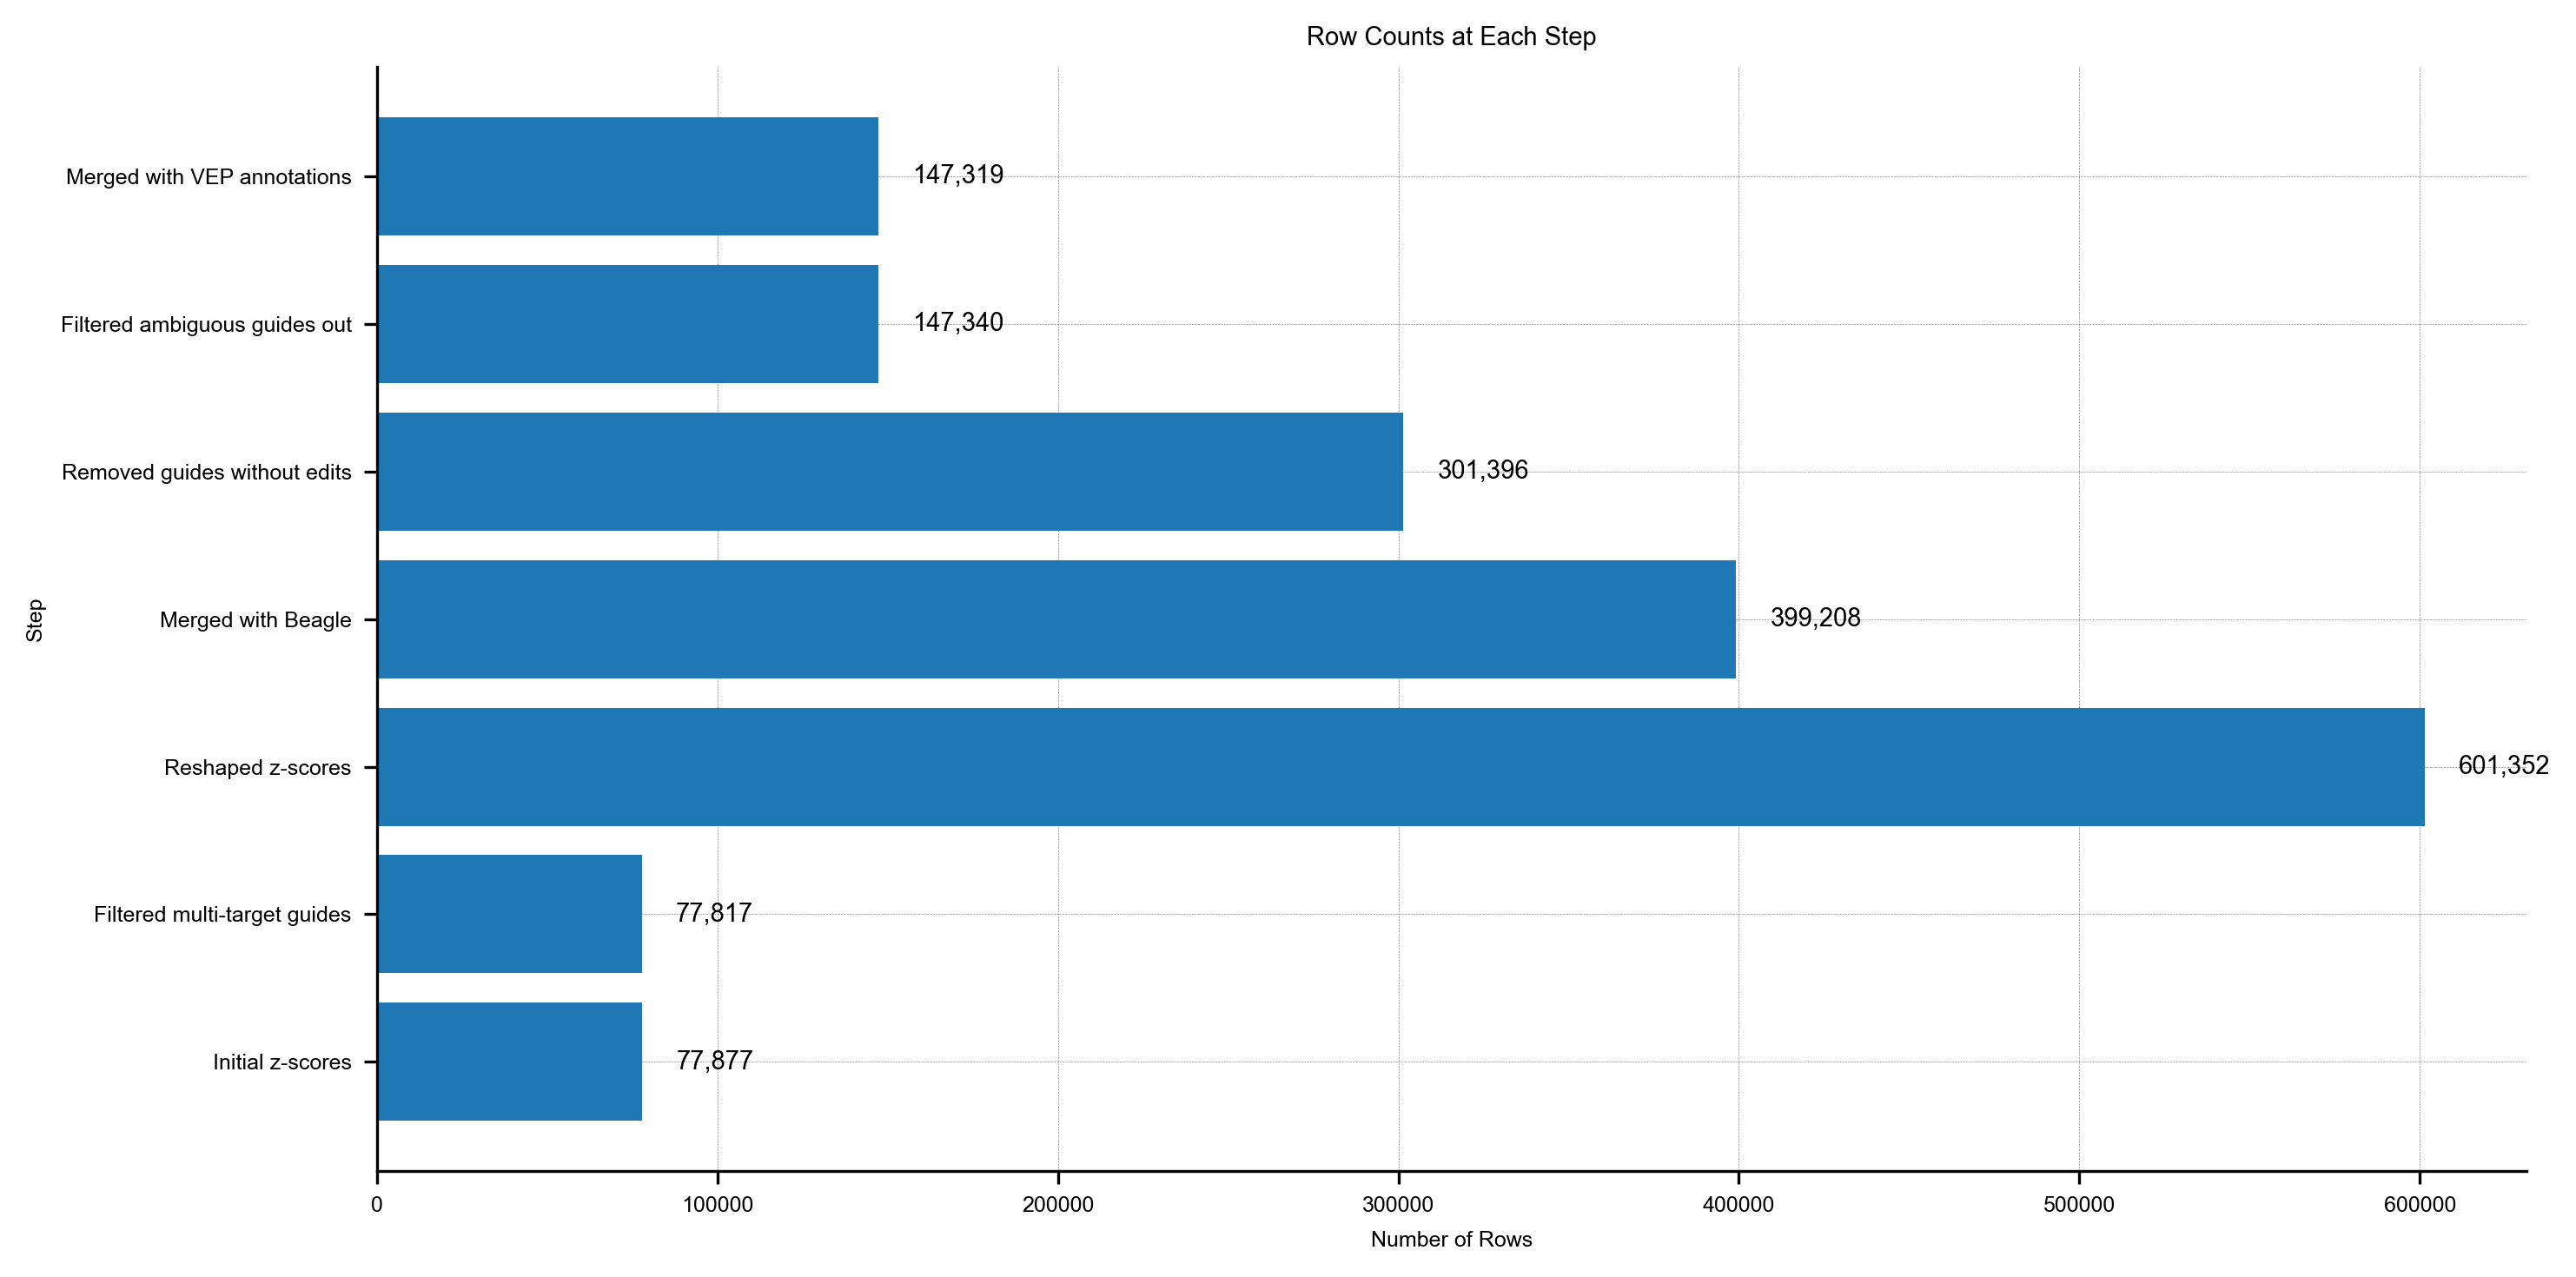

In [314]:
plt.figure(figsize=(10, 5))

# Horizontal bar chart
bars = plt.barh(tracking_row_count["Step"], tracking_row_count["Rows count"])

# Set chart title and axis labels
plt.title("Row Counts at Each Step")
plt.xlabel("Number of Rows")  # Now on the x-axis
plt.ylabel("Step")            # Step names now on the y-axis

# Annotate each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10000, bar.get_y() + bar.get_height()/2, f"{width:,}",
             va='center', fontsize=7)

plt.tight_layout()
plt.show()

### Number of unique guides per step

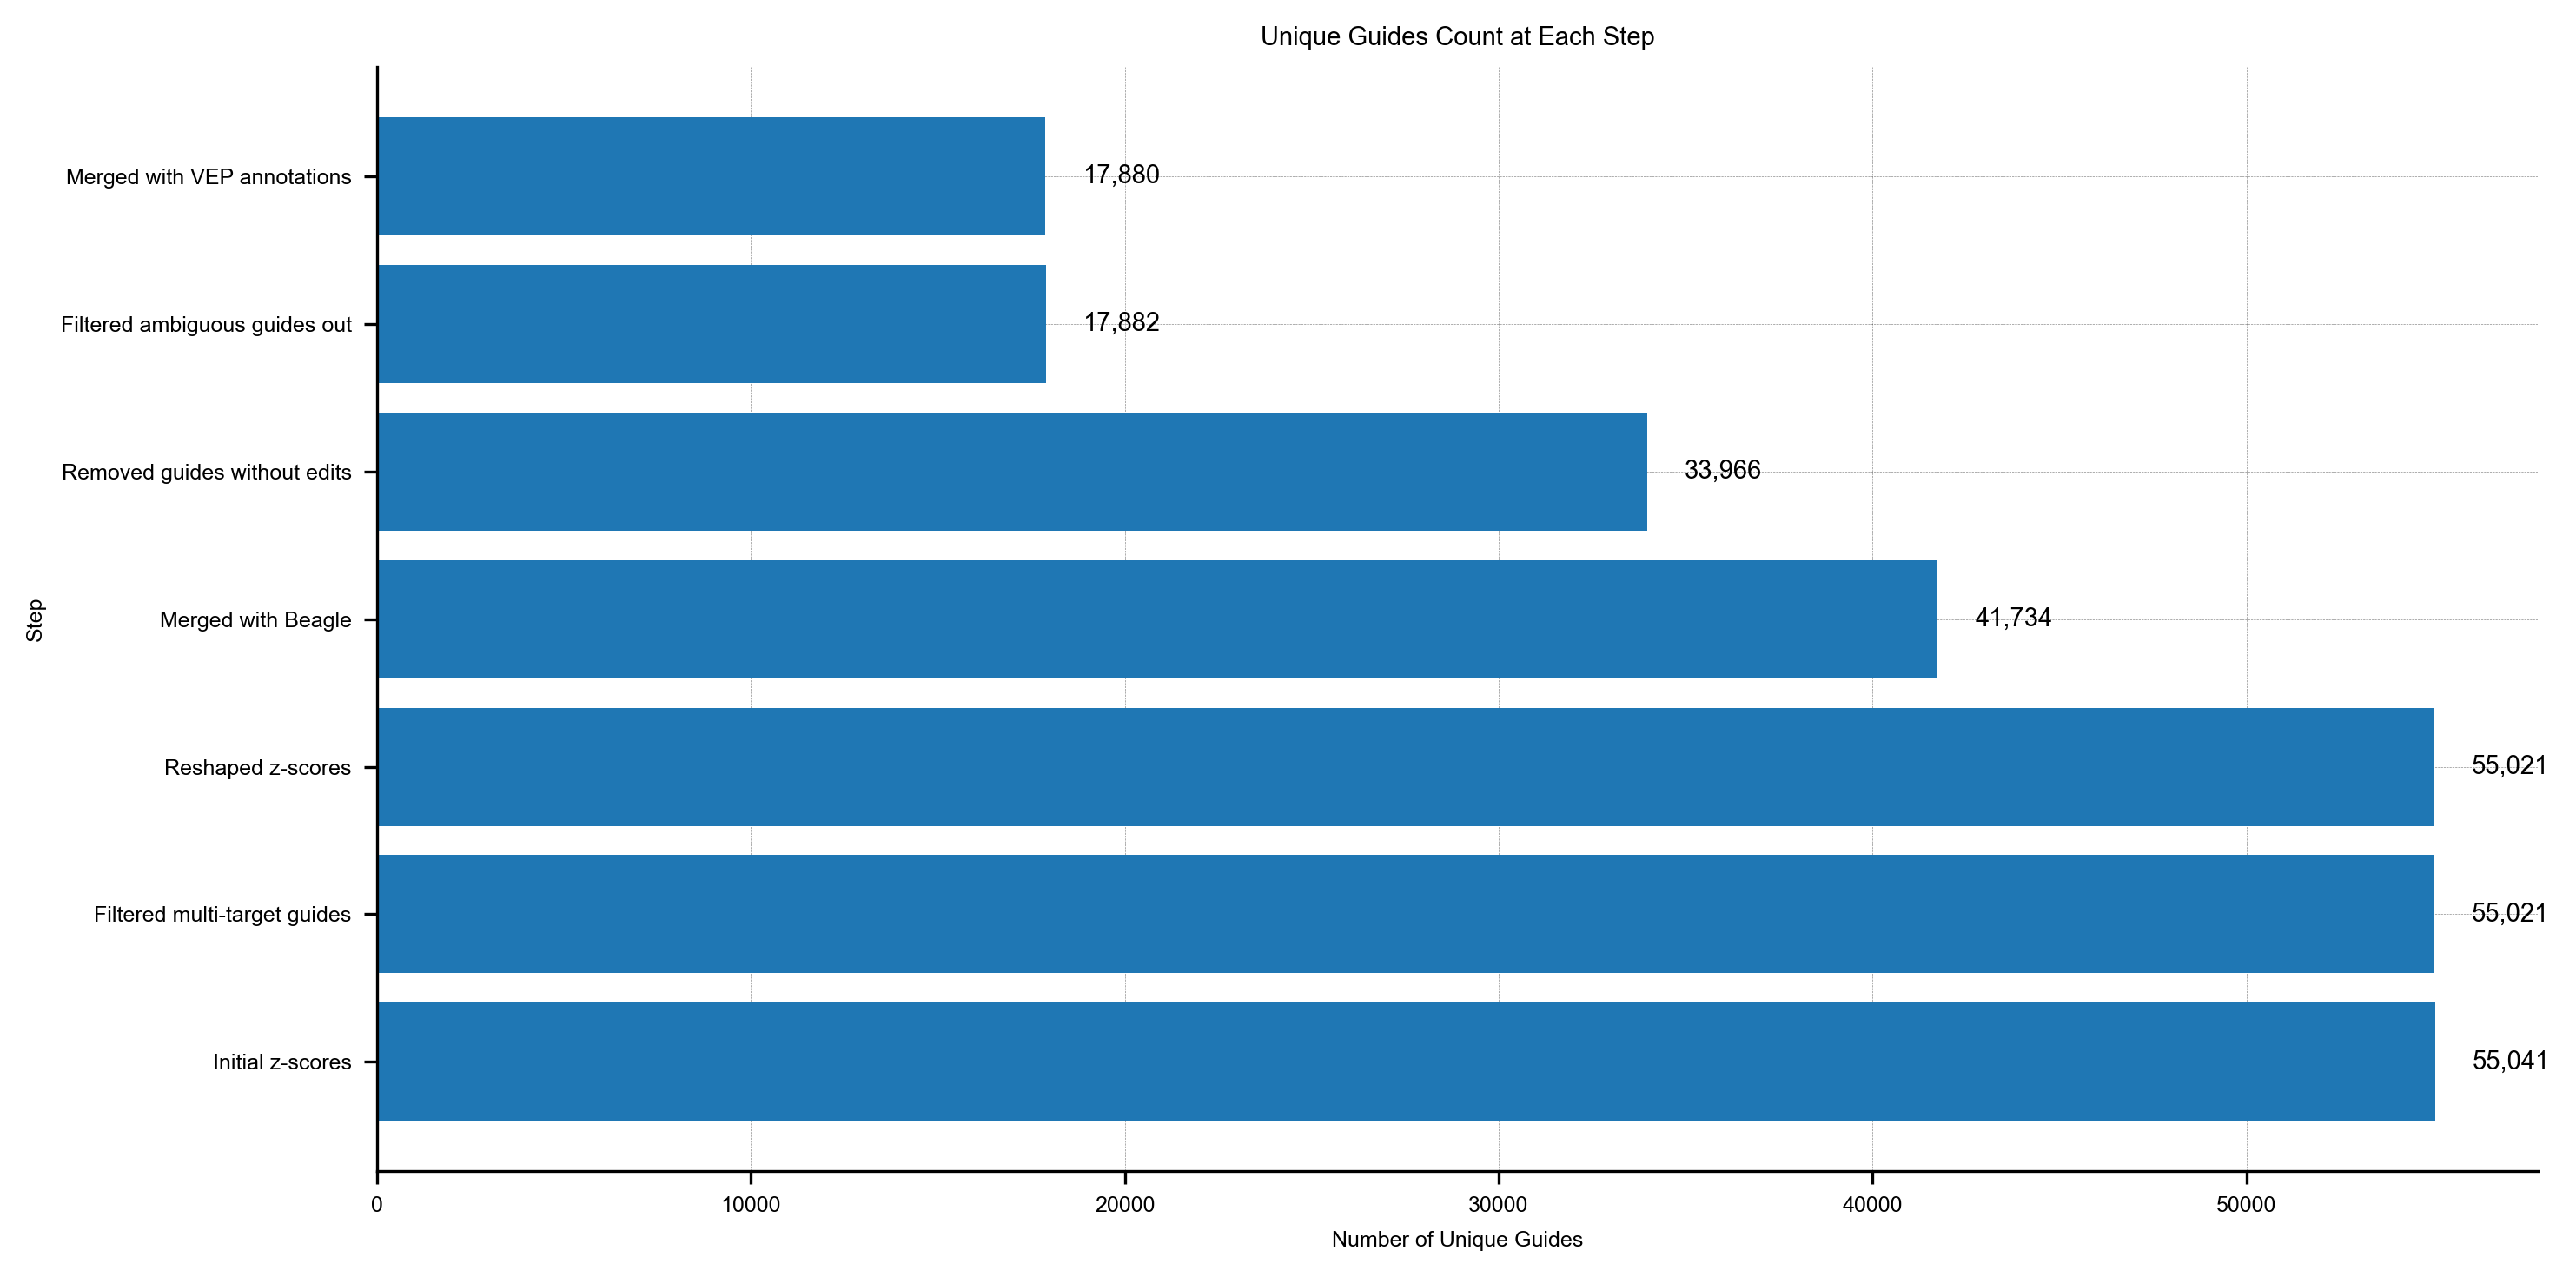

In [315]:
plt.figure(figsize=(10, 5))

# Horizontal bar chart
bars = plt.barh(tracking_unique_guides["Step"], tracking_unique_guides["Unique guides count"])

# Add title and axis labels
plt.title("Unique Guides Count at Each Step")
plt.xlabel("Number of Unique Guides")
plt.ylabel("Step")

# Annotate each bar with the value
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2, f"{width:,}",
             va='center', fontsize=7)

plt.tight_layout()
plt.show()